<a href="https://colab.research.google.com/github/hyunkyung31/coronary-ai-ml-dl/blob/main/jiyoung/ML_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 공통 라이브러리

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV



from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,

    roc_auc_score,
    average_precision_score,

    confusion_matrix,
    classification_report,

    roc_curve,
    precision_recall_curve
)

RANDOM_STATE = 42


print("공통 라이브러리 Import 완료")

공통 라이브러리 Import 완료


# Google Drive 연결 및 데이터 파일 경로 확인

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')


DATA_DIR = Path('/content/drive/MyDrive/clinical_cad/data')


DATA_PATH = DATA_DIR / 'extention of Z-Alizadeh sani dataset.xlsx'


print("데이터 폴더:", DATA_DIR)
print("Excel 파일:", DATA_PATH)

print("\n[경로 확인]")
print("데이터 폴더 존재 여부 :", DATA_DIR.exists())
print("Excel 파일 존재 여부 :", DATA_PATH.exists())

Mounted at /content/drive
데이터 폴더: /content/drive/MyDrive/clinical_cad/data
Excel 파일: /content/drive/MyDrive/clinical_cad/data/extention of Z-Alizadeh sani dataset.xlsx

[경로 확인]
데이터 폴더 존재 여부 : True
Excel 파일 존재 여부 : True


# 데이터 불러오기

In [ ]:
MODEL_SHEET = "Sheet 1 - Table 1"


df = pd.read_excel(
    DATA_PATH,
    sheet_name=MODEL_SHEET
)

print("[1. 데이터 크기]")
print("환자 수(row) :", df.shape[0])
print("전체 변수 수(column) :", df.shape[1])


# 첫 5개 환자 확인
print("\n[2. 첫 5개 행]")
display(df.head())


# 마지막 5개 환자 확인
print("\n[3. 마지막 5개 행]")
display(df.tail())



print("\n[4. 전체 컬럼 목록]")

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")


[1. 데이터 크기]
환자 수(row) : 303
전체 변수 수(column) : 59

[2. 첫 5개 행]


,Age,Weight,Length,Sex,BMI,DM,HTN,Current Smoker,EX-Smoker,FH,...,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,LAD,LCX,RCA,Cath
0,53,90,175,Male,29.387755,0,1,1,0,0,...,39,52,261,50,0,N,Stenotic,Normal,Stenotic,CAD
1,67,70,157,Fmale,28.398718,0,1,0,0,0,...,38,55,165,40,4,N,Stenotic,Stenotic,Normal,CAD
2,54,54,164,Male,20.077335,0,0,1,0,0,...,38,60,230,40,2,mild,Stenotic,Normal,Normal,CAD
3,66,67,158,Fmale,26.838648,0,1,0,0,0,...,18,72,742,55,0,Severe,Normal,Normal,Normal,Normal
4,50,87,153,Fmale,37.165193,0,1,0,0,0,...,55,39,274,50,0,Severe,Normal,Normal,Normal,Normal



[3. 마지막 5개 행]


,Age,Weight,Length,Sex,BMI,DM,HTN,Current Smoker,EX-Smoker,FH,...,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,LAD,LCX,RCA,Cath
298,58,84,168,Male,29.761905,0,0,0,0,0,...,34,58,251,45,0,N,Stenotic,Stenotic,Stenotic,CAD
299,55,64,152,Fmale,27.700831,0,0,0,0,0,...,16,80,377,40,0,mild,Normal,Normal,Normal,Normal
300,48,77,160,Fmale,30.078125,0,1,0,0,1,...,35,55,279,55,0,N,Normal,Normal,Normal,Normal
301,57,90,159,Fmale,35.599858,1,0,0,0,0,...,48,40,208,55,0,N,Normal,Normal,Normal,Normal
302,56,85,170,Fmale,29.411765,0,1,1,0,0,...,32,55,302,55,0,N,Stenotic,Normal,Normal,CAD



[4. 전체 컬럼 목록]
01. Age
02. Weight
03. Length
04. Sex
05. BMI
06. DM
07. HTN
08. Current Smoker
09. EX-Smoker
10. FH
11. Obesity
12. CRF
13. CVA
14. Airway disease
15. Thyroid Disease
16. CHF
17. DLP
18. BP
19. PR
20. Edema
21. Weak Peripheral Pulse
22. Lung rales
23. Systolic Murmur
24. Diastolic Murmur
25. Typical Chest Pain
26. Dyspnea
27. Function Class
28. Atypical
29. Nonanginal
30. Exertional CP
31. LowTH Ang
32. Q Wave
33. St Elevation
34. St Depression
35. Tinversion
36. LVH
37. Poor R Progression
38. BBB
39. FBS
40. CR
41. TG
42. LDL
43. HDL
44. BUN
45. ESR
46. HB
47. K
48. Na
49. WBC
50. Lymph
51. Neut
52. PLT
53. EF-TTE
54. Region RWMA
55. VHD
56. LAD
57. LCX
58. RCA
59. Cath


[1. Target 데이터 타입]
object

[2. Target 고유값]
['CAD' 'Normal']

[3. Target 결측치]
결측치 개수: 0

[4. Target 클래스별 환자 수]
Cath
CAD       216
Normal     87
Name: count, dtype: int64

[5. Target 클래스 비율 (%)]
Cath
CAD       71.29
Normal    28.71
Name: proportion, dtype: float64


NameError: name 'plt' is not defined

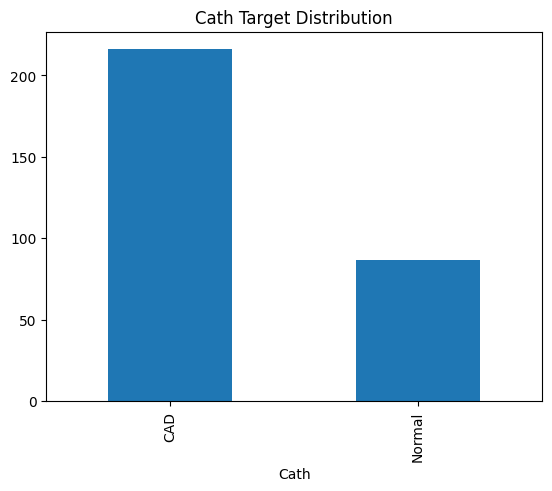

In [ ]:
#  Target 변수(Cath) 검증

TARGET_COLUMN = "Cath"


# ------------------------------------------------------------
# 1) Target의 데이터 타입 확인
# ------------------------------------------------------------
# 문자열(object)인지, 숫자인지 등을 먼저 확인한다.
print("[1. Target 데이터 타입]")
print(df[TARGET_COLUMN].dtype)


# ------------------------------------------------------------
# 2) 실제로 어떤 값들이 들어 있는지 확인
# ------------------------------------------------------------
# CAD / Normal 이외의 예상하지 못한 값이 있는지 검사한다.
print("\n[2. Target 고유값]")
print(df[TARGET_COLUMN].unique())


# ------------------------------------------------------------
# 3) Target 결측치 확인
# ------------------------------------------------------------
# 정답값이 없는 환자는 일반적인 supervised learning에
# 그대로 사용할 수 없으므로 반드시 확인해야 한다.
print("\n[3. Target 결측치]")
print("결측치 개수:", df[TARGET_COLUMN].isna().sum())


# ------------------------------------------------------------
# 4) CAD / Normal 환자 수 확인
# ------------------------------------------------------------
print("\n[4. Target 클래스별 환자 수]")
target_counts = df[TARGET_COLUMN].value_counts(dropna=False)
print(target_counts)


# ------------------------------------------------------------
# 5) CAD / Normal 비율 확인
# ------------------------------------------------------------
# 한 클래스가 지나치게 많은지 확인한다.
# 이후 Accuracy 외에 AUROC, AUPRC, Sensitivity,
# Specificity 등을 함께 봐야 하는 이유와 연결된다.
print("\n[5. Target 클래스 비율 (%)]")

target_ratio = (
    df[TARGET_COLUMN]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

print(target_ratio)


# ------------------------------------------------------------
# 6) 간단한 시각화
# ------------------------------------------------------------
# 데이터 불균형 정도를 눈으로도 확인한다.
target_counts.plot(
    kind="bar",
    title="Cath Target Distribution"
)

plt.xlabel("Cath")
plt.ylabel("Number of patients")
plt.xticks(rotation=0)
plt.show()

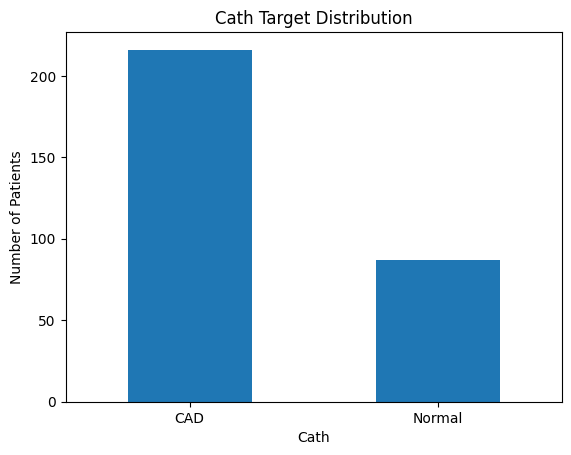

In [ ]:

#  Target 분포 시각화

import matplotlib.pyplot as plt

target_counts.plot(
    kind="bar",
    title="Cath Target Distribution"
)

plt.xlabel("Cath")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.show()

#  X, y 생성

In [ ]:

# ------------------------------------------------------------
# 1) Target 설정
# ------------------------------------------------------------
# CAD    → 1 : Positive class
# Normal → 0 : Negative class
#

y = df["Cath"].map({
    "CAD": 1,
    "Normal": 0
})


# ------------------------------------------------------------
# 2) 1차 Clinical Screening에서 사용할 수 없는 컬럼 정의
# ------------------------------------------------------------
# Cath는 모델이 맞혀야 하는 Target이므로 X에서 제외
# ------------------------------------------------------------

EXCLUDE_COLUMNS = [
    "LAD",
    "LCX",
    "RCA",
    "Cath"
]


# ------------------------------------------------------------
# 3) 모델 입력 X 생성
# ------------------------------------------------------------

X = df.drop(columns=EXCLUDE_COLUMNS).copy()


# ------------------------------------------------------------
# 4) 결과 확인
# ------------------------------------------------------------

print("[1. 전체 원본 데이터]")
print("df shape :", df.shape)

print("\n[2. 모델 입력 데이터 X]")
print("X shape  :", X.shape)

print("\n[3. Target y]")
print("y shape  :", y.shape)


# ------------------------------------------------------------
# 5) Target 변환 확인
# ------------------------------------------------------------

print("\n[4. y 고유값]")
print(sorted(y.unique()))

print("\n[5. y 클래스별 환자 수]")
print(y.value_counts().sort_index())


# ------------------------------------------------------------
# 6) 데이터 누수 컬럼이 X에 남아있는지 검사
# ------------------------------------------------------------

leakage_columns = [
    col for col in ["LAD", "LCX", "RCA", "Cath"]
    if col in X.columns
]

print("\n[6. X에 남아 있는 Leakage 컬럼]")
print(leakage_columns)


# ------------------------------------------------------------
# 7) X의 처음/마지막 컬럼 확인
# ------------------------------------------------------------

print("\n[7. X의 처음 10개 컬럼]")
print(X.columns[:10].tolist())

print("\n[8. X의 마지막 10개 컬럼]")
print(X.columns[-10:].tolist())


# ------------------------------------------------------------
# 8) 안전 검증
# ------------------------------------------------------------

assert X.shape == (303, 55), \
    f"예상한 X 크기 (303, 55)와 다릅니다: {X.shape}"

assert y.shape[0] == 303, \
    f"예상한 y 길이 303과 다릅니다: {y.shape[0]}"

assert y.isna().sum() == 0, \
    "Target 변환 과정에서 NaN이 발생했습니다."

assert set(y.unique()) == {0, 1}, \
    f"Target이 0/1 이외의 값을 포함합니다: {y.unique()}"

assert len(leakage_columns) == 0, \
    f"Leakage 컬럼이 X에 남아 있습니다: {leakage_columns}"


print("\n✅ STEP 5 검증 완료")


[1. 전체 원본 데이터]
df shape : (303, 59)

[2. 모델 입력 데이터 X]
X shape  : (303, 55)

[3. Target y]
y shape  : (303,)

[4. y 고유값]
[np.int64(0), np.int64(1)]

[5. y 클래스별 환자 수]
Cath
0     87
1    216
Name: count, dtype: int64

[6. X에 남아 있는 Leakage 컬럼]
[]

[7. X의 처음 10개 컬럼]
['Age', 'Weight', 'Length', 'Sex', 'BMI', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH']

[8. X의 마지막 10개 컬럼]
['HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE', 'Region RWMA', 'VHD']

✅ STEP 5 검증 완료


In [ ]:
# ------------------------------------------------------------
# 1) 각 Feature의 pandas 데이터 타입 확인
# ------------------------------------------------------------

print("=" * 80)
print("[1. Feature 데이터 타입]")
print("=" * 80)

print(X.dtypes)


# ------------------------------------------------------------
# 2) 각 Feature의 고유값 개수 확인
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("[2. Feature별 고유값 개수]")
print("=" * 80)

unique_counts = X.nunique(dropna=False).sort_values()

print(unique_counts)


# ------------------------------------------------------------
# 3) 고유값이 10개 이하인 변수의 실제 값 확인
# ------------------------------------------------------------


print("\n" + "=" * 80)
print("[3. 고유값 10개 이하 Feature의 실제 값]")
print("=" * 80)

for column in X.columns:

    unique_values = X[column].dropna().unique()

    if len(unique_values) <= 10:

        print(f"\n[{column}]")
        print(f"데이터 타입 : {X[column].dtype}")
        print(f"고유값 개수 : {len(unique_values)}")
        print(f"고유값      : {unique_values}")


# ------------------------------------------------------------
# 4) 입력 Feature 전체의 결측치 확인
# ------------------------------------------------------------


print("\n" + "=" * 80)
print("[4. 입력 Feature 결측치]")
print("=" * 80)

missing_counts = X.isna().sum()

features_with_missing = missing_counts[missing_counts > 0]

if len(features_with_missing) == 0:
    print("✅ 입력 Feature에 결측치가 없습니다.")
else:
    print(features_with_missing)


# ------------------------------------------------------------
# 5) 값이 하나밖에 없는 Feature 확인
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("[5. Zero-Variance Feature]")
print("=" * 80)

zero_variance_features = [
    column
    for column in X.columns
    if X[column].nunique(dropna=False) <= 1
]

print(zero_variance_features)


# ------------------------------------------------------------
# 6) 숫자형 / 문자열형 컬럼 개수 확인
# ------------------------------------------------------------

numeric_columns = X.select_dtypes(include=np.number).columns.tolist()

non_numeric_columns = X.select_dtypes(exclude=np.number).columns.tolist()


print("\n" + "=" * 80)
print("[6. pandas 기준 데이터 타입 요약]")
print("=" * 80)

print("숫자형 Feature 수 :", len(numeric_columns))
print("문자열/기타 Feature 수 :", len(non_numeric_columns))

print("\n문자열/기타 Feature:")
print(non_numeric_columns)

[1. Feature 데이터 타입]
Age                        int64
Weight                     int64
Length                     int64
Sex                       object
BMI                      float64
DM                         int64
HTN                        int64
Current Smoker             int64
EX-Smoker                  int64
FH                         int64
Obesity                   object
CRF                       object
CVA                       object
Airway disease            object
Thyroid Disease           object
CHF                       object
DLP                       object
BP                         int64
PR                         int64
Edema                      int64
Weak Peripheral Pulse     object
Lung rales                object
Systolic Murmur           object
Diastolic Murmur          object
Typical Chest Pain         int64
Dyspnea                   object
Function Class             int64
Atypical                  object
Nonanginal                object
Exertional CP          

# Feature 확인 및 확정

In [ ]:
continuous_features = [
    "Age",
    "Weight",
    "Length",
    "BMI",
    "BP",
    "PR",
    "FBS",
    "CR",
    "TG",
    "LDL",
    "HDL",
    "BUN",
    "ESR",
    "HB",
    "K",
    "Na",
    "WBC",
    "Lymph",
    "Neut",
    "PLT",
    "EF-TTE"
]

binary_numeric_features = [
    "DM",
    "HTN",
    "Current Smoker",
    "EX-Smoker",
    "FH",
    "Edema",
    "Typical Chest Pain",
    "Q Wave",
    "St Elevation",
    "St Depression",
    "Tinversion"
]


binary_yn_features = [
    "Obesity",
    "CRF",
    "CVA",
    "Airway disease",
    "Thyroid Disease",
    "CHF",
    "DLP",
    "Weak Peripheral Pulse",
    "Lung rales",
    "Systolic Murmur",
    "Diastolic Murmur",
    "Dyspnea",
    "Atypical",
    "Nonanginal",
    "LowTH Ang",
    "LVH",
    "Poor R Progression"
]



sex_feature = ["Sex"]
nominal_features = ["BBB"]



ordered_numeric_features = [
    "Function Class",
    "Region RWMA"
]

ordered_string_features = ["VHD"]



drop_features = ["Exertional CP"]


# Feature 개수 검증


specified_features = (
    continuous_features
    + binary_numeric_features
    + binary_yn_features
    + sex_feature
    + nominal_features
    + ordered_numeric_features
    + ordered_string_features
    + drop_features
)


print("=" * 80)
print("[Feature Specification 요약]")
print("=" * 80)

print("Continuous            :", len(continuous_features))
print("Binary numeric        :", len(binary_numeric_features))
print("Binary Y/N            :", len(binary_yn_features))
print("Sex                   :", len(sex_feature))
print("Nominal               :", len(nominal_features))
print("Ordered numeric       :", len(ordered_numeric_features))
print("Ordered string        :", len(ordered_string_features))
print("Drop                   :", len(drop_features))

print("\n분류된 전체 Feature 수 :", len(specified_features))
print("원본 X Feature 수     :", X.shape[1])



# 누락/중복 Feature 확인


missing_from_spec = set(X.columns) - set(specified_features)
duplicated_in_spec = [
    feature
    for feature in set(specified_features)
    if specified_features.count(feature) > 1
]


print("\n[Specification에 빠진 Feature]")
print(sorted(missing_from_spec))

print("\n[Specification에서 중복된 Feature]")
print(sorted(duplicated_in_spec))



# 안전 검증

assert len(specified_features) == 55, \
    f"55개 Feature가 모두 분류되지 않았습니다: {len(specified_features)}"

assert len(missing_from_spec) == 0, \
    f"Specification에서 누락된 Feature가 있습니다: {missing_from_spec}"

assert len(duplicated_in_spec) == 0, \
    f"중복 분류된 Feature가 있습니다: {duplicated_in_spec}"

assert drop_features == ["Exertional CP"]

print("\n✅ STEP 7-A Feature Specification 검증 완료")

[Feature Specification 요약]
Continuous            : 21
Binary numeric        : 11
Binary Y/N            : 17
Sex                   : 1
Nominal               : 1
Ordered numeric       : 2
Ordered string        : 1
Drop                   : 1

분류된 전체 Feature 수 : 55
원본 X Feature 수     : 55

[Specification에 빠진 Feature]
[]

[Specification에서 중복된 Feature]
[]

✅ STEP 7-A Feature Specification 검증 완료


In [ ]:
# ============================================================
# Baseline 모델 입력 Feature 최종 확정
# ============================================================

# ------------------------------------------------------------
# 1) Baseline 입력 데이터 생성
# ------------------------------------------------------------

X_baseline = X.drop(
    columns=drop_features
).copy()


# ------------------------------------------------------------
# 2) 데이터 크기 확인
# ------------------------------------------------------------

print("=" * 80)
print("[1. Baseline Feature 데이터 크기]")
print("=" * 80)

print("원본 X shape        :", X.shape)
print("Baseline X shape    :", X_baseline.shape)
print("Target y shape      :", y.shape)


# ------------------------------------------------------------
# 3) 제거된 Feature 확인
# ------------------------------------------------------------

removed_features = (
    set(X.columns)
    - set(X_baseline.columns)
)

print("\n" + "=" * 80)
print("[2. Baseline에서 제거된 Feature]")
print("=" * 80)

print(sorted(removed_features))


# ------------------------------------------------------------
# 4) Leakage Feature가 다시 포함되지 않았는지 확인
# ------------------------------------------------------------

forbidden_features = [
    "LAD",
    "LCX",
    "RCA",
    "Cath"
]

remaining_forbidden = [
    feature
    for feature in forbidden_features
    if feature in X_baseline.columns
]

print("\n" + "=" * 80)
print("[3. Leakage Feature 재확인]")
print("=" * 80)

print(remaining_forbidden)


# ------------------------------------------------------------
# 5) 원본 문자열 범주가 아직 유지되는지 확인
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("[4. 전처리 전 주요 범주 확인]")
print("=" * 80)

check_features = [
    "Sex",
    "CRF",
    "DLP",
    "BBB",
    "VHD"
]

for feature in check_features:
    print(
        f"{feature:10s} : "
        f"{X_baseline[feature].unique()}"
    )


# ------------------------------------------------------------
# 6) 행 순서가 y와 동일하게 유지되는지 확인
# ------------------------------------------------------------


print("\n" + "=" * 80)
print("[5. X / y Index 일치 여부]")
print("=" * 80)

print(
    "Index 동일 :",
    X_baseline.index.equals(y.index)
)


# ------------------------------------------------------------
# 7) 안전 검증
# ------------------------------------------------------------

assert X_baseline.shape == (303, 54), \
    f"예상 크기 (303, 54)와 다릅니다: {X_baseline.shape}"

assert removed_features == {"Exertional CP"}, \
    f"예상 외 Feature가 제거되었습니다: {removed_features}"

assert len(remaining_forbidden) == 0, \
    f"Leakage Feature가 남아 있습니다: {remaining_forbidden}"

assert X_baseline.index.equals(y.index), \
    "X와 y의 환자 Index가 일치하지 않습니다."


print("\n✅ STEP 7-B Baseline Feature Set 확정 완료")

[1. Baseline Feature 데이터 크기]
원본 X shape        : (303, 55)
Baseline X shape    : (303, 54)
Target y shape      : (303,)

[2. Baseline에서 제거된 Feature]
['Exertional CP']

[3. Leakage Feature 재확인]
[]

[4. 전처리 전 주요 범주 확인]
Sex        : ['Male' 'Fmale']
CRF        : ['N' 'Y']
DLP        : ['Y' 'N']
BBB        : ['N' 'LBBB' 'RBBB']
VHD        : ['N' 'mild' 'Severe' 'Moderate']

[5. X / y Index 일치 여부]
Index 동일 : True

✅ STEP 7-B Baseline Feature Set 확정 완료


# 전처리

In [ ]:
# ============================================================
# STEP 8-A. LR / SVM 공통 Preprocessor 정의
# ============================================================

from sklearn.preprocessing import OrdinalEncoder


# ------------------------------------------------------------
# 1) Continuous Feature Pipeline
# ------------------------------------------------------------

continuous_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ------------------------------------------------------------
# 2) 이미 0/1인 Binary Numeric Feature
# ------------------------------------------------------------

binary_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        )
    ]
)


# ------------------------------------------------------------
# 3) Y / N Binary Feature
# ------------------------------------------------------------

binary_yn_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OrdinalEncoder(
                categories=[
                    ["N", "Y"]
                    for _ in binary_yn_features
                ],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ]
)


# ------------------------------------------------------------
# 4) Sex
# ------------------------------------------------------------

sex_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OrdinalEncoder(
                categories=[
                    ["Fmale", "Male"]
                ],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ]
)


# ------------------------------------------------------------
# 5) BBB
# ------------------------------------------------------------

bbb_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                categories=[
                    ["N", "LBBB", "RBBB"]
                ],
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ------------------------------------------------------------
# 6) Ordered Numeric Feature
# ------------------------------------------------------------

ordered_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ------------------------------------------------------------
# 7) VHD
# ------------------------------------------------------------

vhd_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OrdinalEncoder(
                categories=[
                    ["N", "mild", "Moderate", "Severe"]
                ],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ------------------------------------------------------------
# 8) 전체 ColumnTransformer 구성
# ------------------------------------------------------------


preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            continuous_pipeline,
            continuous_features
        ),
        (
            "binary_numeric",
            binary_numeric_pipeline,
            binary_numeric_features
        ),
        (
            "binary_yn",
            binary_yn_pipeline,
            binary_yn_features
        ),
        (
            "sex",
            sex_pipeline,
            sex_feature
        ),
        (
            "bbb",
            bbb_pipeline,
            nominal_features
        ),
        (
            "ordered_numeric",
            ordered_numeric_pipeline,
            ordered_numeric_features
        ),
        (
            "vhd",
            vhd_pipeline,
            ordered_string_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


print("✅ STEP 8-A Preprocessor 정의 완료")

✅ STEP 8-A Preprocessor 정의 완료


In [ ]:
# ============================================================
# Clinical 데이터의 예상하지 못한 범주는 오류로 처리
# ============================================================

# ------------------------------------------------------------
# Y/N Binary
# ------------------------------------------------------------

binary_yn_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OrdinalEncoder(
                categories=[
                    ["N", "Y"]
                    for _ in binary_yn_features
                ],
                handle_unknown="error"
            )
        )
    ]
)


# ------------------------------------------------------------
# Sex
# ------------------------------------------------------------

sex_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OrdinalEncoder(
                categories=[
                    ["Fmale", "Male"]
                ],
                handle_unknown="error"
            )
        )
    ]
)


# ------------------------------------------------------------
# BBB
# ------------------------------------------------------------

bbb_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                categories=[
                    ["N", "LBBB", "RBBB"]
                ],

                # N을 기준 범주로 사용
                drop="first",

                # 정의되지 않은 BBB 값은 허용하지 않는다.
                handle_unknown="error",

                sparse_output=False
            )
        )
    ]
)


# ------------------------------------------------------------
# VHD
# ------------------------------------------------------------

vhd_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OrdinalEncoder(
                categories=[
                    ["N", "mild", "Moderate", "Severe"]
                ],
                handle_unknown="error"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ------------------------------------------------------------
# 수정된 Pipeline을 이용해 전체 Preprocessor 다시 정의
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            continuous_pipeline,
            continuous_features
        ),
        (
            "binary_numeric",
            binary_numeric_pipeline,
            binary_numeric_features
        ),
        (
            "binary_yn",
            binary_yn_pipeline,
            binary_yn_features
        ),
        (
            "sex",
            sex_pipeline,
            sex_feature
        ),
        (
            "bbb",
            bbb_pipeline,
            nominal_features
        ),
        (
            "ordered_numeric",
            ordered_numeric_pipeline,
            ordered_numeric_features
        ),
        (
            "vhd",
            vhd_pipeline,
            ordered_string_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


print("✅ STEP 8-A Preprocessor 안전 설정 보완 완료")

✅ STEP 8-A Preprocessor 안전 설정 보완 완료


In [ ]:
# 검증
from collections import Counter


preprocessor_input_features = (
    continuous_features
    + binary_numeric_features
    + binary_yn_features
    + sex_feature
    + nominal_features
    + ordered_numeric_features
    + ordered_string_features
)


print("=" * 80)
print("[1. Raw Feature 개수 확인]")
print("=" * 80)

print("X_baseline Feature 수     :", X_baseline.shape[1])
print(
    "Preprocessor 지정 Feature 수 :",
    len(preprocessor_input_features)
)


# 빠진 Feature 확인

missing_features = (
    set(X_baseline.columns)
    - set(preprocessor_input_features)
)


print("\n" + "=" * 80)
print("[2. Preprocessor에서 누락된 Feature]")
print("=" * 80)

print(sorted(missing_features))


# 존재하지 않는 Feature를 잘못 지정했는지 확인


unknown_features = (
    set(preprocessor_input_features)
    - set(X_baseline.columns)
)


print("\n" + "=" * 80)
print("[3. X_baseline에 없는 잘못된 Feature]")
print("=" * 80)

print(sorted(unknown_features))



# 중복 지정된 Feature 확인


feature_counter = Counter(
    preprocessor_input_features
)

duplicated_features = [
    feature
    for feature, count in feature_counter.items()
    if count > 1
]


print("\n" + "=" * 80)
print("[4. 중복 지정된 Feature]")
print("=" * 80)

print(sorted(duplicated_features))

# Binary Numeric 값 검증

print("\n" + "=" * 80)
print("[5. Binary Numeric 값 검증]")
print("=" * 80)

binary_numeric_invalid = {}

for feature in binary_numeric_features:

    values = set(
        X_baseline[feature]
        .dropna()
        .unique()
    )

    if not values.issubset({0, 1}):
        binary_numeric_invalid[feature] = values


print(binary_numeric_invalid)


# Y/N Binary 값 검증
print("\n" + "=" * 80)
print("[6. Y/N Binary 값 검증]")
print("=" * 80)

binary_yn_invalid = {}

for feature in binary_yn_features:

    values = set(
        X_baseline[feature]
        .dropna()
        .unique()
    )

    if not values.issubset({"N", "Y"}):
        binary_yn_invalid[feature] = values


print(binary_yn_invalid)


# 주요 Categorical Feature 값 검증
print("\n" + "=" * 80)
print("[7. 주요 Categorical 값 검증]")
print("=" * 80)

expected_categories = {
    "Sex": {"Fmale", "Male"},
    "BBB": {"N", "LBBB", "RBBB"},
    "VHD": {"N", "mild", "Moderate", "Severe"}
}


categorical_invalid = {}

for feature, allowed_values in expected_categories.items():

    actual_values = set(
        X_baseline[feature]
        .dropna()
        .unique()
    )

    if not actual_values.issubset(allowed_values):
        categorical_invalid[feature] = actual_values


print(categorical_invalid)



# Ordered Numeric 범위 확인
print("\n" + "=" * 80)
print("[8. Ordered Numeric 값 확인]")
print("=" * 80)

print(
    "Function Class :",
    sorted(
        X_baseline["Function Class"]
        .unique()
    )
)

print(
    "Region RWMA    :",
    sorted(
        X_baseline["Region RWMA"]
        .unique()
    )
)


# 변환 후 예상 Feature 수 계산
expected_transformed_feature_count = (
    len(continuous_features)
    + len(binary_numeric_features)
    + len(binary_yn_features)
    + len(sex_feature)
    + 2  # BBB → LBBB / RBBB
    + len(ordered_numeric_features)
    + len(ordered_string_features)
)


print("\n" + "=" * 80)
print("[9. 변환 후 예상 Feature 수]")
print("=" * 80)

print(
    "예상 모델 입력 Feature 수 :",
    expected_transformed_feature_count
)


# 최종 안전 검증
assert len(preprocessor_input_features) == 54, \
    "Preprocessor Raw Feature 수가 54개가 아닙니다."

assert len(missing_features) == 0, \
    f"누락 Feature 존재: {missing_features}"

assert len(unknown_features) == 0, \
    f"잘못 지정된 Feature 존재: {unknown_features}"

assert len(duplicated_features) == 0, \
    f"중복 Feature 존재: {duplicated_features}"

assert len(binary_numeric_invalid) == 0, \
    f"Binary Numeric 이상값 존재: {binary_numeric_invalid}"

assert len(binary_yn_invalid) == 0, \
    f"Y/N Binary 이상값 존재: {binary_yn_invalid}"

assert len(categorical_invalid) == 0, \
    f"Categorical 이상값 존재: {categorical_invalid}"

assert expected_transformed_feature_count == 55, \
    "예상 transformed Feature 수가 55가 아닙니다."


print("\n✅ STEP 8-B Preprocessor 입력 명세 검증 완료")

[1. Raw Feature 개수 확인]
X_baseline Feature 수     : 54
Preprocessor 지정 Feature 수 : 54

[2. Preprocessor에서 누락된 Feature]
[]

[3. X_baseline에 없는 잘못된 Feature]
[]

[4. 중복 지정된 Feature]
[]

[5. Binary Numeric 값 검증]
{}

[6. Y/N Binary 값 검증]
{}

[7. 주요 Categorical 값 검증]
{}

[8. Ordered Numeric 값 확인]
Function Class : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Region RWMA    : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

[9. 변환 후 예상 Feature 수]
예상 모델 입력 Feature 수 : 55

✅ STEP 8-B Preprocessor 입력 명세 검증 완료


# Logistic Regression

In [ ]:
# Baseline

from sklearn.metrics import make_scorer

# pipeline 정의
lr_baseline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                penalty="l2",        # 기본 L2 정규화
                C=1.0,               # 기본 regularization strength
                solver="liblinear",  # 소규모 이진분류에 적합
                class_weight=None,   # 아직 class balancing 적용 안 함
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)



# Stratified 10-Fold 정의

# 현재 데이터
# CAD    = 216 (71.29%)
# Normal = 87  (28.71%)

# 일반 KFold보다 StratifiedKFold가 분류 문제에 더 적절함


cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)



# Specificity 평가 함수 정의
specificity_scorer = make_scorer(
    recall_score,
    pos_label=0
)


#평가 지표
scoring = {
    "AUROC": "roc_auc",
    "AUPRC": "average_precision",
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Sensitivity": "recall",
    "Specificity": specificity_scorer,
    "F1": "f1"
}



# 10-Fold Cross Validation
lr_cv_results = cross_validate(
    estimator=lr_baseline,
    X=X_baseline,
    y=y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)



# Fold별 Validation 결과
lr_fold_results = pd.DataFrame({
    "Fold": range(1, 11),

    "AUROC": lr_cv_results["test_AUROC"],
    "AUPRC": lr_cv_results["test_AUPRC"],
    "Accuracy": lr_cv_results["test_Accuracy"],
    "Precision": lr_cv_results["test_Precision"],
    "Sensitivity": lr_cv_results["test_Sensitivity"],
    "Specificity": lr_cv_results["test_Specificity"],
    "F1": lr_cv_results["test_F1"]
})


print("=" * 90)
print("[1. Logistic Regression - Fold별 Validation 성능]")
print("=" * 90)

display(
    lr_fold_results.round(4)
)



# 평균 ± 표준편차 계산
metric_columns = [
    "AUROC",
    "AUPRC",
    "Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1"
]


summary_rows = []

for metric in metric_columns:

    values = lr_fold_results[metric]

    summary_rows.append({
        "Metric": metric,
        "Mean": values.mean(),
        "Std": values.std(ddof=1),
        "Min": values.min(),
        "Max": values.max()
    })


lr_summary = pd.DataFrame(summary_rows)


print("\n" + "=" * 90)
print("[2. Logistic Regression - 10-Fold 평균 성능]")
print("=" * 90)

display(
    lr_summary.round(4)
)


# Training vs Validation AUROC 확인
# Training AUROC와 Validation AUROC의 차이가 지나치게 크면 Overfitting 가능성

train_auc_mean = np.mean(
    lr_cv_results["train_AUROC"]
)

validation_auc_mean = np.mean(
    lr_cv_results["test_AUROC"]
)


print("\n" + "=" * 90)
print("[3. Training vs Validation AUROC]")
print("=" * 90)

print(
    f"Training AUROC 평균   : {train_auc_mean:.4f}"
)

print(
    f"Validation AUROC 평균 : {validation_auc_mean:.4f}"
)

print(
    f"AUROC 차이            : "
    f"{train_auc_mean - validation_auc_mean:.4f}"
)



# 단순 Majority Baseline 확인
majority_baseline_accuracy = (
    y.value_counts(normalize=True).max()
)


print("\n" + "=" * 90)
print("[4. Majority Class 기준 Accuracy]")
print("=" * 90)

print(
    f"Always-majority Accuracy : "
    f"{majority_baseline_accuracy:.4f}"
)


print("\n✅ STEP 9-A Logistic Regression Baseline 완료")

[1. Logistic Regression - Fold별 Validation 성능]


,Fold,AUROC,AUPRC,Accuracy,Precision,Sensitivity,Specificity,F1
0,1,0.9545,0.9836,0.8387,0.8696,0.9091,0.6667,0.8889
1,2,1.0000,1.0000,0.9677,1.0000,0.9545,1.0000,0.9767
2,3,0.8990,0.9559,0.8387,0.9048,0.8636,0.7778,0.8837
3,4,0.9830,0.9938,0.8667,0.8462,1.0000,0.5000,0.9167
4,5,0.9432,0.9824,0.8667,0.9500,0.8636,0.8750,0.9048
5,6,0.9148,0.9625,0.9000,0.9130,0.9545,0.7500,0.9333
6,7,0.9048,0.9635,0.8333,0.9444,0.8095,0.8889,0.8718
7,8,0.9630,0.9872,0.8667,1.0000,0.8095,1.0000,0.8947
8,9,0.7989,0.9222,0.7000,0.8000,0.7619,0.5556,0.7805
9,10,0.8995,0.9632,0.8333,0.8333,0.9524,0.5556,0.8889



[2. Logistic Regression - 10-Fold 평균 성능]


,Metric,Mean,Std,Min,Max
0,AUROC,0.9261,0.0571,0.7989,1.0000
1,AUPRC,0.9714,0.0229,0.9222,1.0000
2,Accuracy,0.8512,0.0671,0.7000,0.9677
3,Precision,0.9061,0.0688,0.8000,1.0000
4,Sensitivity,0.8879,0.0785,0.7619,1.0000
5,Specificity,0.7569,0.1842,0.5000,1.0000
6,F1,0.8940,0.0501,0.7805,0.9767



[3. Training vs Validation AUROC]
Training AUROC 평균   : 0.9780
Validation AUROC 평균 : 0.9261
AUROC 차이            : 0.0519

[4. Majority Class 기준 Accuracy]
Always-majority Accuracy : 0.7129

✅ STEP 9-A Logistic Regression Baseline 완료


[1. Logistic Regression OOF Confusion Matrix]
[[ 66  21]
 [ 24 192]]

[환자 수 기준]
TN - Normal → Normal : 66
FP - Normal → CAD    : 21
FN - CAD → Normal    : 24
TP - CAD → CAD       : 192

[2. OOF 전체 성능]
AUROC      : 0.9236
AUPRC      : 0.9682
Accuracy   : 0.8515
Precision  : 0.9014
Sensitivity: 0.8889
Specificity: 0.7586
F1         : 0.8951
NPV        : 0.7333


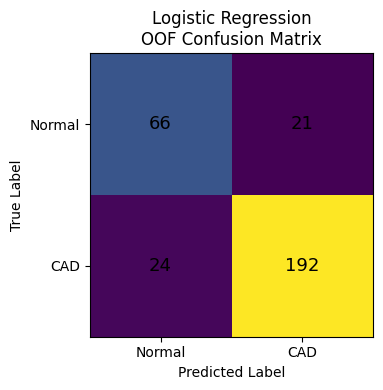


✅ STEP 9-B Logistic Regression OOF 평가 완료


In [ ]:
from sklearn.model_selection import cross_val_predict

# OOF Class Prediction
lr_oof_pred = cross_val_predict(
    estimator=lr_baseline,
    X=X_baseline,
    y=y,
    cv=cv,
    method="predict",
    n_jobs=-1
)

# OOF Probability Prediction
lr_oof_proba = cross_val_predict(
    estimator=lr_baseline,
    X=X_baseline,
    y=y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]



# Confusion Matrix
cm = confusion_matrix(
    y,
    lr_oof_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


print("=" * 80)
print("[1. Logistic Regression OOF Confusion Matrix]")
print("=" * 80)

print(cm)


print("\n[환자 수 기준]")
print(f"TN - Normal → Normal : {tn}")
print(f"FP - Normal → CAD    : {fp}")
print(f"FN - CAD → Normal    : {fn}")
print(f"TP - CAD → CAD       : {tp}")



# OOF 기반 주요 성능 계산


oof_accuracy = accuracy_score(
    y,
    lr_oof_pred
)

oof_precision = precision_score(
    y,
    lr_oof_pred
)

oof_sensitivity = recall_score(
    y,
    lr_oof_pred
)

oof_specificity = (
    tn / (tn + fp)
)

oof_f1 = f1_score(
    y,
    lr_oof_pred
)

oof_auroc = roc_auc_score(
    y,
    lr_oof_proba
)

oof_auprc = average_precision_score(
    y,
    lr_oof_proba
)


# NPV 추가 계산


npv = (
    tn / (tn + fn)
)


print("\n" + "=" * 80)
print("[2. OOF 전체 성능]")
print("=" * 80)

print(f"AUROC      : {oof_auroc:.4f}")
print(f"AUPRC      : {oof_auprc:.4f}")
print(f"Accuracy   : {oof_accuracy:.4f}")
print(f"Precision  : {oof_precision:.4f}")
print(f"Sensitivity: {oof_sensitivity:.4f}")
print(f"Specificity: {oof_specificity:.4f}")
print(f"F1         : {oof_f1:.4f}")
print(f"NPV        : {npv:.4f}")


# Confusion Matrix 시각화
fig, ax = plt.subplots(figsize=(5, 4))

ax.imshow(cm)

ax.set_title(
    "Logistic Regression\n"
    "OOF Confusion Matrix"
)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["Normal", "CAD"]
)

ax.set_yticks([0, 1])
ax.set_yticklabels(
    ["Normal", "CAD"]
)


# 각 칸에 실제 환자 수 표시
for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=13
        )

plt.tight_layout()
plt.show()


print(
    "\n✅ STEP 9-B Logistic Regression "
    "OOF 평가 완료"
)

# Logistic Regression Nested CV 튜닝
- 각 outer fold에서 최적 파라미터를 찾으면서 oof 예측 동시 저장

In [ ]:
# Logistic Regression Hyperparameter Tuning
# Nested Cross Validation


# Outer 10-Fold: 최종 일반화 성능 평가
# Inner 5-Fold: C / penalty / class_weight 선택
# Outer Validation 환자에서 성능을 평가 가능

from sklearn.base import clone
from sklearn.model_selection import GridSearchCV



# 튜닝용 Logistic Regression Pipeline
lr_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                solver="liblinear",
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)



# Hyperparameter Search Space
# 넓은 범위를 coarse search
# 만약 최적 C가 범위 끝(0.01 또는 100)에 계속 걸리면 이후 범위를 확장

lr_param_grid = {
    "model__C": [
        0.01,
        0.1,
        1.0,
        10.0,
        100.0
    ],

    "model__penalty": [
        "l1",
        "l2"
    ],

    "model__class_weight": [
        None,
        "balanced"
    ]
}


print(
    "총 Hyperparameter 조합 수 :",
    5 * 2 * 2
)



# Outer 10-Fold
# Baseline과 동일한 split 조건

outer_cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)



# OOF 결과 저장 공간

lr_tuned_oof_pred = np.zeros(
    len(y),
    dtype=int
)

lr_tuned_oof_proba = np.zeros(
    len(y),
    dtype=float
)


fold_results = []
best_params_results = []



# Nested Cross Validation

for fold, (train_idx, valid_idx) in enumerate(
    outer_cv.split(X_baseline, y),
    start=1
):

    print(
        f"\n===== Outer Fold {fold}/10 ====="
    )

    # Outer Train / Validation 분리


    X_train = X_baseline.iloc[train_idx]
    X_valid = X_baseline.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]



    # Inner 5-Fold
    # Hyperparameter 선택은Outer Train 내부에서만 수행


    inner_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE + fold
    )


    # GridSearchCV
    # C / penalty / class_weight 중 Inner CV AUROC가 가장 높은 조합을 선택

    # AUROC를 선택 기준으로 쓰는 이유: 특정 threshold 0.5에 의존하지 않고모델의 전반적인 판별력을 먼저 비교하기 위함

    grid_search = GridSearchCV(
        estimator=clone(lr_tuning_pipeline),
        param_grid=lr_param_grid,
        scoring=scoring,
        refit="AUROC",
        cv=inner_cv,
        n_jobs=-1,
        return_train_score=False
    )


    # Outer Train에서만 튜닝
    grid_search.fit(
        X_train,
        y_train
    )


    # Outer Validation 예측
    valid_pred = grid_search.predict(
        X_valid
    )

    valid_proba = grid_search.predict_proba(
        X_valid
    )[:, 1]


    # 해당 환자들의 OOF 위치에 저장
    lr_tuned_oof_pred[valid_idx] = valid_pred
    lr_tuned_oof_proba[valid_idx] = valid_proba


    # Fold별 Confusion Matrix
    fold_cm = confusion_matrix(
        y_valid,
        valid_pred,
        labels=[0, 1]
    )

    fold_tn, fold_fp, fold_fn, fold_tp = (
        fold_cm.ravel()
    )

    # Fold 성능 저장
    fold_results.append({
        "Fold": fold,

        "AUROC":
            roc_auc_score(
                y_valid,
                valid_proba
            ),

        "AUPRC":
            average_precision_score(
                y_valid,
                valid_proba
            ),

        "Accuracy":
            accuracy_score(
                y_valid,
                valid_pred
            ),

        "Precision":
            precision_score(
                y_valid,
                valid_pred,
                zero_division=0
            ),

        "Sensitivity":
            recall_score(
                y_valid,
                valid_pred,
                zero_division=0
            ),

        "Specificity":
            fold_tn /
            (fold_tn + fold_fp),

        "F1":
            f1_score(
                y_valid,
                valid_pred,
                zero_division=0
            )
    })


    # 해당 Outer Fold에서 선택된 parameter 기록
    best_params_results.append({
        "Fold": fold,

        "C":
            grid_search.best_params_[
                "model__C"
            ],

        "Penalty":
            grid_search.best_params_[
                "model__penalty"
            ],

        "Class Weight":
            grid_search.best_params_[
                "model__class_weight"
            ],

        "Inner Best AUROC":
            grid_search.best_score_
    })


    print(
        "Best Params :",
        grid_search.best_params_
    )

    print(
        f"Inner Best AUROC : "
        f"{grid_search.best_score_:.4f}"
    )



# Fold별 성능 DataFrame


lr_tuned_fold_results = pd.DataFrame(
    fold_results
)


print("\n" + "=" * 90)
print(
    "[1. Tuned Logistic Regression "
    "- Outer Fold 성능]"
)
print("=" * 90)

display(
    lr_tuned_fold_results.round(4)
)



# Outer Fold 평균 ± 표준편차
metric_columns = [
    "AUROC",
    "AUPRC",
    "Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1"
]


tuned_summary_rows = []

for metric in metric_columns:

    values = lr_tuned_fold_results[
        metric
    ]

    tuned_summary_rows.append({
        "Metric": metric,
        "Mean": values.mean(),
        "Std": values.std(ddof=1),
        "Min": values.min(),
        "Max": values.max()
    })


lr_tuned_summary = pd.DataFrame(
    tuned_summary_rows
)


print("\n" + "=" * 90)
print(
    "[2. Tuned Logistic Regression "
    "- Nested CV 평균]"
)
print("=" * 90)

display(
    lr_tuned_summary.round(4)
)



# Fold별 선택된 Hyperparameter
lr_best_params_df = pd.DataFrame(
    best_params_results
)


print("\n" + "=" * 90)
print(
    "[3. Outer Fold별 선택된 "
    "Hyperparameter]"
)
print("=" * 90)

display(
    lr_best_params_df.round(4)
)


# 가장 자주 선택된 Parameter 조합
print("\n" + "=" * 90)
print(
    "[4. Hyperparameter 조합 선택 빈도]"
)
print("=" * 90)

param_frequency = (
    lr_best_params_df[
        [
            "C",
            "Penalty",
            "Class Weight"
        ]
    ]
    .value_counts(dropna=False)
    .reset_index(name="Count")
)

display(param_frequency)


print(
    "\n✅ STEP 9-C Logistic Regression "
    "Nested CV 튜닝 완료"
)

총 Hyperparameter 조합 수 : 20

===== Outer Fold 1/10 =====
Best Params : {'model__C': 1.0, 'model__class_weight': None, 'model__penalty': 'l2'}
Inner Best AUROC : 0.9103

===== Outer Fold 2/10 =====
Best Params : {'model__C': 1.0, 'model__class_weight': None, 'model__penalty': 'l1'}
Inner Best AUROC : 0.9173

===== Outer Fold 3/10 =====
Best Params : {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l2'}
Inner Best AUROC : 0.9409

===== Outer Fold 4/10 =====
Best Params : {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l2'}
Inner Best AUROC : 0.9163

===== Outer Fold 5/10 =====
Best Params : {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l1'}
Inner Best AUROC : 0.9236

===== Outer Fold 6/10 =====
Best Params : {'model__C': 1.0, 'model__class_weight': None, 'model__penalty': 'l2'}
Inner Best AUROC : 0.9363

===== Outer Fold 7/10 =====
Best Params : {'model__C': 1.0, 'model__class_weight': None, 'model__penalty': 'l1'}
Inner Best AU

,Fold,AUROC,AUPRC,Accuracy,Precision,Sensitivity,Specificity,F1
0,1,0.9545,0.9836,0.8387,0.8696,0.9091,0.6667,0.8889
1,2,1.0000,1.0000,0.9355,1.0000,0.9091,1.0000,0.9524
2,3,0.9293,0.9690,0.8387,0.9048,0.8636,0.7778,0.8837
3,4,0.9716,0.9901,0.8667,0.8462,1.0000,0.5000,0.9167
4,5,0.8352,0.9393,0.7667,0.9412,0.7273,0.8750,0.8205
5,6,0.9148,0.9625,0.9000,0.9130,0.9545,0.7500,0.9333
6,7,0.9206,0.9699,0.7667,0.8182,0.8571,0.5556,0.8372
7,8,0.9841,0.9940,0.9333,1.0000,0.9048,1.0000,0.9500
8,9,0.7831,0.9068,0.7000,0.7727,0.8095,0.4444,0.7907
9,10,0.9048,0.9632,0.8000,0.8000,0.9524,0.4444,0.8696



[2. Tuned Logistic Regression - Nested CV 평균]


,Metric,Mean,Std,Min,Max
0,AUROC,0.9198,0.0672,0.7831,1.0000
1,AUPRC,0.9678,0.0280,0.9068,1.0000
2,Accuracy,0.8346,0.0773,0.7000,0.9355
3,Precision,0.8866,0.0794,0.7727,1.0000
4,Sensitivity,0.8887,0.0788,0.7273,1.0000
5,Specificity,0.7014,0.2139,0.4444,1.0000
6,F1,0.8843,0.0555,0.7907,0.9524



[3. Outer Fold별 선택된 Hyperparameter]


,Fold,C,Penalty,Class Weight,Inner Best AUROC
0,1,1.0,l2,None,0.9103
1,2,1.0,l1,None,0.9173
2,3,0.1,l2,None,0.9409
3,4,0.1,l2,None,0.9163
4,5,0.1,l1,balanced,0.9236
5,6,1.0,l2,None,0.9363
6,7,1.0,l1,None,0.9201
7,8,1.0,l1,None,0.9210
8,9,0.1,l2,None,0.9421
9,10,0.1,l2,None,0.9261



[4. Hyperparameter 조합 선택 빈도]


,C,Penalty,Class Weight,Count
0,0.1,l2,NaN,4
1,1.0,l1,NaN,3
2,1.0,l2,NaN,2
3,0.1,l1,balanced,1



✅ STEP 9-C Logistic Regression Nested CV 튜닝 완료


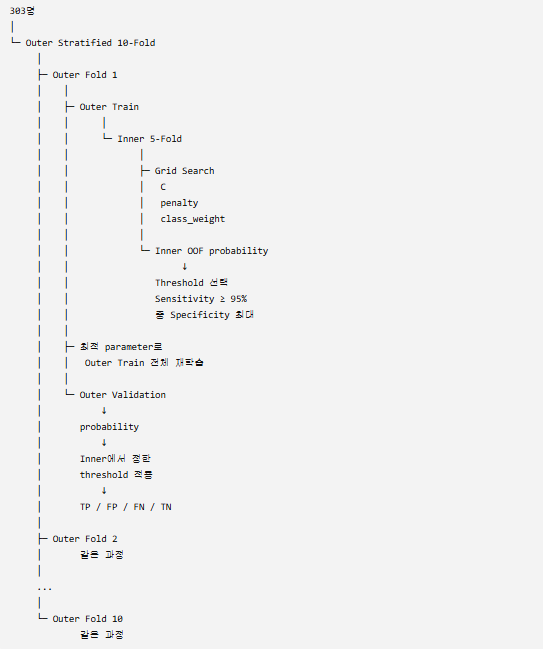

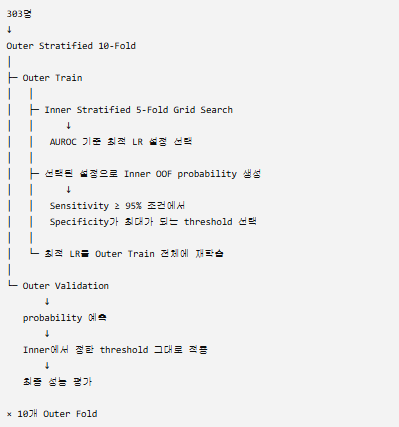

최종 평가 구조
- outer validation 환자는 모델 설정을 고를 때와 threshold 정할 때 모두 사용되지 않음
- outer 10 개 fold 결과를 합친 것이 Nested Stratified CV 기반 내부 검증 성능

threshold 정의
Inner CV에서 Sensitivity >= 95%를 만족하는 threshold 중 Specificity가 가장 높은 threshold 를 선택한다.


# 최종 nested CV

In [ ]:
# Final Nested CV
# Inner CV: hyperparameter + threshold 선택
# Outer CV: 최종 일반화 성능 평가
# Outer validation 데이터는 모델/threshold 선택에 사용하지 않음

from sklearn.base import clone
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_val_predict
)


TARGET_SENSITIVITY = 0.95



# LR Pipeline
lr_nested_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                solver="liblinear",
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)



# Hyperparameter Grid
# 이전 Nested Grid Search와 동일한 탐색 범위

lr_param_grid = {

    "model__C": [
        0.01,
        0.1,
        1.0,
        10.0,
        100.0
    ],

    "model__penalty": [
        "l1",
        "l2"
    ],

    "model__class_weight": [
        None,
        "balanced"
    ]
}


# Outer 10-Fold 정의
outer_cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)


# 전체 환자의 Outer OOF 결과 저장 공간
lr_nested_oof_proba = np.zeros(
    len(y),
    dtype=float
)

lr_nested_oof_pred = np.zeros(
    len(y),
    dtype=int
)



# 결과 저장 리스트
nested_fold_results = []

nested_selection_results = []



# Outer CV
for fold, (outer_train_idx, outer_valid_idx) in enumerate(
    outer_cv.split(X_baseline, y),
    start=1
):

    print("\n" + "=" * 90)
    print(f"Outer Fold {fold}/10")
    print("=" * 90)

    # Outer Train / Validation
    X_outer_train = X_baseline.iloc[
        outer_train_idx
    ]

    X_outer_valid = X_baseline.iloc[
        outer_valid_idx
    ]

    y_outer_train = y.iloc[
        outer_train_idx
    ]

    y_outer_valid = y.iloc[
        outer_valid_idx
    ]


    # 8) Inner 5-Fold
    inner_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE + fold
    )



    # Inner Grid Search
    grid_search = GridSearchCV(
        estimator=clone(
            lr_nested_pipeline
        ),
        param_grid=lr_param_grid,
        scoring="roc_auc",
        cv=inner_cv,
        refit=True,
        n_jobs=-1
    )
    grid_search.fit(
        X_outer_train,
        y_outer_train
    )
    best_params = (
        grid_search.best_params_
    )
    best_inner_auc = (
        grid_search.best_score_
    )
    print(
        "Best Params:",
        best_params
    )
    print(
        f"Inner Grid Search AUROC: "
        f"{best_inner_auc:.4f}"
    )


    # 선택된 Hyperparameter로 Inner OOF probability 생성
    best_inner_model = clone(
        grid_search.best_estimator_
    )


    inner_oof_proba = cross_val_predict(
        estimator=best_inner_model,

        X=X_outer_train,
        y=y_outer_train,

        cv=inner_cv,

        method="predict_proba",

        n_jobs=-1
    )[:, 1]



    # Inner OOF Threshold Optimization
    # Threshold 후보를 임의의 0.01 간격으로 제한하지 않고 실제 Inner OOF probability 값을 후보로 사용
    # 실제 prediction이 바뀌는 지점을정확하게 탐색 가능
    threshold_candidates = np.unique(
        np.concatenate(
            [
                np.array([0.0]),
                inner_oof_proba,
                np.array([1.0])
            ]
        )
    )

    threshold_records = []
    for threshold in threshold_candidates:

        inner_pred = (
            inner_oof_proba >= threshold
        ).astype(int)


        inner_cm = confusion_matrix(
            y_outer_train,
            inner_pred,
            labels=[0, 1]
        )


        inner_tn, inner_fp, inner_fn, inner_tp = (
            inner_cm.ravel()
        )


        inner_sensitivity = (
            inner_tp /
            (inner_tp + inner_fn)
        )


        inner_specificity = (
            inner_tn /
            (inner_tn + inner_fp)
        )


        threshold_records.append({

            "Threshold":
                threshold,
            "Sensitivity":
                inner_sensitivity,
            "Specificity":
                inner_specificity,
            "TN":
                inner_tn,
            "FP":
                inner_fp,
            "FN":
                inner_fn,
            "TP":
                inner_tp
        })

    inner_threshold_df = pd.DataFrame(
        threshold_records
    )


    # Sensitivity >= 95% 조건 만족 후보
    eligible_thresholds = (
        inner_threshold_df[
            inner_threshold_df[
                "Sensitivity"
            ] >= TARGET_SENSITIVITY
        ]
        .copy()
    )


    selected_row = (
        eligible_thresholds
        .sort_values(
            by=[
                "Specificity",
                "Threshold"
            ],
            ascending=[
                False,
                False
            ]
        )
        .iloc[0]
    )


    selected_threshold = float(
        selected_row["Threshold"]
    )


    inner_selected_sensitivity = float(
        selected_row["Sensitivity"]
    )

    inner_selected_specificity = float(
        selected_row["Specificity"]
    )


    print(
        f"Selected Threshold: "
        f"{selected_threshold:.4f}"
    )

    print(
        f"Inner Sensitivity: "
        f"{inner_selected_sensitivity:.4f}"
    )

    print(
        f"Inner Specificity: "
        f"{inner_selected_specificity:.4f}"
    )



    # Outer Train 전체로 최종 모델 학습
    final_outer_model = (
        grid_search.best_estimator_
    )
    # Outer Validation probability
    outer_valid_proba = (
        final_outer_model.predict_proba(
            X_outer_valid
        )[:, 1]
    )

    # Threshold는 반드시 Inner에서 고른 값을 사용
    outer_valid_pred = (
        outer_valid_proba
        >= selected_threshold
    ).astype(int)


    # 전체 OOF 위치에 저장
    lr_nested_oof_proba[
        outer_valid_idx
    ] = outer_valid_proba


    lr_nested_oof_pred[
        outer_valid_idx
    ] = outer_valid_pred

    # Outer Validation 평가
    outer_cm = confusion_matrix(
        y_outer_valid,
        outer_valid_pred,
        labels=[0, 1]
    )

    tn_o, fp_o, fn_o, tp_o = (
        outer_cm.ravel()
    )

    outer_sensitivity = (
        tp_o /
        (tp_o + fn_o)
    )

    outer_specificity = (
        tn_o /
        (tn_o + fp_o)
    )

    outer_precision = (
        tp_o /
        (tp_o + fp_o)
        if (tp_o + fp_o) > 0
        else 0
    )

    outer_npv = (
        tn_o /
        (tn_o + fn_o)
        if (tn_o + fn_o) > 0
        else 0
    )


    outer_accuracy = accuracy_score(
        y_outer_valid,
        outer_valid_pred
    )

    outer_f1 = f1_score(
        y_outer_valid,
        outer_valid_pred,
        zero_division=0
    )

    outer_auroc = roc_auc_score(
        y_outer_valid,
        outer_valid_proba
    )

    outer_auprc = average_precision_score(
        y_outer_valid,
        outer_valid_proba
    )

    # Fold 평가 결과 저장
    nested_fold_results.append({

        "Fold": fold,
        "Threshold":
            selected_threshold,
        "AUROC":
            outer_auroc,
        "AUPRC":
            outer_auprc,
        "Accuracy":
            outer_accuracy,
        "Precision":
            outer_precision,
        "Sensitivity":
            outer_sensitivity,
        "Specificity":
            outer_specificity,
        "NPV":
            outer_npv,
        "F1":
            outer_f1,
        "TN":
            tn_o,
        "FP":
            fp_o,
        "FN":
            fn_o,
        "TP":
            tp_o
    })


    # Hyperparameter + Threshold 선택 결과 저장
    nested_selection_results.append({

        "Fold":
            fold,

        "C":
            best_params[
                "model__C"
            ],

        "Penalty":
            best_params[
                "model__penalty"
            ],

        "Class Weight":
            best_params[
                "model__class_weight"
            ],

        "Inner AUROC":
            best_inner_auc,

        "Threshold":
            selected_threshold,

        "Inner Sensitivity":
            inner_selected_sensitivity,

        "Inner Specificity":
            inner_selected_specificity
    })



# Outer Fold 결과표
lr_final_nested_folds = pd.DataFrame(
    nested_fold_results
)


print("\n" + "=" * 110)
print(
    "[1. LR Final Nested CV - "
    "Outer Fold 성능]"
)
print("=" * 110)


display(
    lr_final_nested_folds.round(4)
)



# Outer Fold 평균 ± 표준편차
summary_metrics = [

    "AUROC",
    "AUPRC",
    "Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "NPV",
    "F1"
]


summary_rows = []
for metric in summary_metrics:
    values = (
        lr_final_nested_folds[
            metric
        ]
    )
    summary_rows.append({
        "Metric":
            metric,
        "Mean":
            values.mean(),
        "Std":
            values.std(ddof=1),
        "Min":
            values.min(),
        "Max":
            values.max()
    })

lr_final_nested_summary = pd.DataFrame(
    summary_rows
)


print("\n" + "=" * 110)
print(
    "[2. LR Final Nested CV - "
    "Outer 평균 성능]"
)
print("=" * 110)


display(
    lr_final_nested_summary.round(4)
)

# Fold별 선택된 설정
lr_final_selection_df = pd.DataFrame(nested_selection_results)
print("\n" + "=" * 110)
print(
    "[3. Fold별 선택된 "
    "Hyperparameter + Threshold]"
)
print("=" * 110)

display(
    lr_final_selection_df.round(4)
)



# Nested Outer OOF 전체 Confusion Matrix
nested_cm = confusion_matrix(
    y,
    lr_nested_oof_pred,
    labels=[0, 1]
)

nested_tn, nested_fp, nested_fn, nested_tp = (
    nested_cm.ravel()
)

print("\n" + "=" * 110)
print(
    "[4. Nested Outer OOF "
    "전체 Confusion Matrix]"
)
print("=" * 110)


print(nested_cm)

print()
print(f"TN : {nested_tn}")
print(f"FP : {nested_fp}")
print(f"FN : {nested_fn}")
print(f"TP : {nested_tp}")


# Nested Outer OOF 전체 성능
nested_oof_auroc = roc_auc_score(
    y,
    lr_nested_oof_proba
)
nested_oof_auprc = average_precision_score(
    y,
    lr_nested_oof_proba
)
nested_oof_accuracy = accuracy_score(
    y,
    lr_nested_oof_pred
)
nested_oof_precision = precision_score(
    y,
    lr_nested_oof_pred,
    zero_division=0
)
nested_oof_sensitivity = recall_score(
    y,
    lr_nested_oof_pred
)
nested_oof_specificity = (
    nested_tn /
    (nested_tn + nested_fp)
)
nested_oof_npv = (
    nested_tn /
    (nested_tn + nested_fn)
)
nested_oof_f1 = f1_score(
    y,
    lr_nested_oof_pred,
    zero_division=0
)

print("\n" + "=" * 110)
print(
    "[5. Nested Outer OOF "
    "전체 성능]"
)
print("=" * 110)


print(
    f"AUROC      : "
    f"{nested_oof_auroc:.4f}"
)

print(
    f"AUPRC      : "
    f"{nested_oof_auprc:.4f}"
)
print(
    f"Accuracy   : "
    f"{nested_oof_accuracy:.4f}"
)
print(
    f"Precision  : "
    f"{nested_oof_precision:.4f}"
)
print(
    f"Sensitivity: "
    f"{nested_oof_sensitivity:.4f}"
)
print(
    f"Specificity: "
    f"{nested_oof_specificity:.4f}"
)
print(
    f"NPV        : "
    f"{nested_oof_npv:.4f}"
)
print(
    f"F1         : "
    f"{nested_oof_f1:.4f}"
)

# Threshold 안정성
print("\n" + "=" * 110)
print(
    "[6. Inner에서 선택된 Threshold 분포]"
)
print("=" * 110)
print(
    "Mean   :",
    round(
        lr_final_selection_df[
            "Threshold"
        ].mean(),
        4
    )
)
print(
    "Median :",
    round(
        lr_final_selection_df[
            "Threshold"
        ].median(),
        4
    )
)

print(
    "Std    :",
    round(
        lr_final_selection_df[
            "Threshold"
        ].std(ddof=1),
        4
    )
)

print(
    "Min    :",
    round(
        lr_final_selection_df[
            "Threshold"
        ].min(),
        4
    )
)

print(
    "Max    :",
    round(
        lr_final_selection_df[
            "Threshold"
        ].max(),
        4
    )
)


print(
    "\n✅ STEP 10-C "
    "LR Final Nested CV 완료"
)


Outer Fold 1/10
Best Params: {'model__C': 1.0, 'model__class_weight': None, 'model__penalty': 'l2'}
Inner Grid Search AUROC: 0.9103
Selected Threshold: 0.3018
Inner Sensitivity: 0.9536
Inner Specificity: 0.5128

Outer Fold 2/10
Best Params: {'model__C': 1.0, 'model__class_weight': None, 'model__penalty': 'l1'}
Inner Grid Search AUROC: 0.9173
Selected Threshold: 0.3095
Inner Sensitivity: 0.9536
Inner Specificity: 0.5769

Outer Fold 3/10
Best Params: {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l2'}
Inner Grid Search AUROC: 0.9409
Selected Threshold: 0.4557
Inner Sensitivity: 0.9536
Inner Specificity: 0.6538

Outer Fold 4/10
Best Params: {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l2'}
Inner Grid Search AUROC: 0.9163
Selected Threshold: 0.4104
Inner Sensitivity: 0.9536
Inner Specificity: 0.5696

Outer Fold 5/10
Best Params: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l1'}
Inner Grid Search AUROC: 0.9236
Selected Thre

,Fold,Threshold,AUROC,AUPRC,Accuracy,Precision,Sensitivity,Specificity,NPV,F1,TN,FP,FN,TP
0,1,0.3018,0.9545,0.9836,0.8387,0.8400,0.9545,0.5556,0.8333,0.8936,5,4,1,21
1,2,0.3095,1.0000,1.0000,0.9677,0.9565,1.0000,0.8889,1.0000,0.9778,8,1,0,22
2,3,0.4557,0.9293,0.9690,0.8387,0.8696,0.9091,0.6667,0.7500,0.8889,6,3,2,20
3,4,0.4104,0.9716,0.9901,0.8667,0.8462,1.0000,0.5000,1.0000,0.9167,4,4,0,22
4,5,0.3111,0.8352,0.9393,0.8000,0.8077,0.9545,0.3750,0.7500,0.8750,3,5,1,21
5,6,0.2791,0.9148,0.9625,0.8667,0.8462,1.0000,0.5000,1.0000,0.9167,4,4,0,22
6,7,0.2937,0.9206,0.9699,0.8000,0.8261,0.9048,0.5556,0.7143,0.8636,5,4,2,19
7,8,0.2499,0.9841,0.9940,0.9333,0.9524,0.9524,0.8889,0.8889,0.9524,8,1,1,20
8,9,0.4609,0.7831,0.9068,0.7000,0.7727,0.8095,0.4444,0.5000,0.7907,4,5,4,17
9,10,0.3767,0.9048,0.9632,0.7667,0.7692,0.9524,0.3333,0.7500,0.8511,3,6,1,20



[2. LR Final Nested CV - Outer 평균 성능]


,Metric,Mean,Std,Min,Max
0,AUROC,0.9198,0.0672,0.7831,1.0000
1,AUPRC,0.9678,0.0280,0.9068,1.0000
2,Accuracy,0.8378,0.0779,0.7000,0.9677
3,Precision,0.8487,0.0643,0.7692,0.9565
4,Sensitivity,0.9437,0.0583,0.8095,1.0000
5,Specificity,0.5708,0.1923,0.3333,0.8889
6,NPV,0.8187,0.1600,0.5000,1.0000
7,F1,0.8926,0.0530,0.7907,0.9778



[3. Fold별 선택된 Hyperparameter + Threshold]


,Fold,C,Penalty,Class Weight,Inner AUROC,Threshold,Inner Sensitivity,Inner Specificity
0,1,1.0,l2,None,0.9103,0.3018,0.9536,0.5128
1,2,1.0,l1,None,0.9173,0.3095,0.9536,0.5769
2,3,0.1,l2,None,0.9409,0.4557,0.9536,0.6538
3,4,0.1,l2,None,0.9163,0.4104,0.9536,0.5696
4,5,0.1,l1,balanced,0.9236,0.3111,0.9536,0.5949
5,6,1.0,l2,None,0.9363,0.2791,0.9536,0.5823
6,7,1.0,l1,None,0.9201,0.2937,0.9538,0.5385
7,8,1.0,l1,None,0.9210,0.2499,0.9538,0.5385
8,9,0.1,l2,None,0.9421,0.4609,0.9538,0.6795
9,10,0.1,l2,None,0.9261,0.3767,0.9538,0.5385



[4. Nested Outer OOF 전체 Confusion Matrix]
[[ 50  37]
 [ 12 204]]

TN : 50
FP : 37
FN : 12
TP : 204

[5. Nested Outer OOF 전체 성능]
AUROC      : 0.9170
AUPRC      : 0.9647
Accuracy   : 0.8383
Precision  : 0.8465
Sensitivity: 0.9444
Specificity: 0.5747
NPV        : 0.8065
F1         : 0.8928

[6. Inner에서 선택된 Threshold 분포]
Mean   : 0.3449
Median : 0.3103
Std    : 0.0755
Min    : 0.2499
Max    : 0.4609

✅ STEP 10-C LR Final Nested CV 완료


# 시각화

LR 결과 폴더 : /content/drive/MyDrive/clinical_cad/results/logistic_regression
Nested Outer OOF AUROC : 0.9170


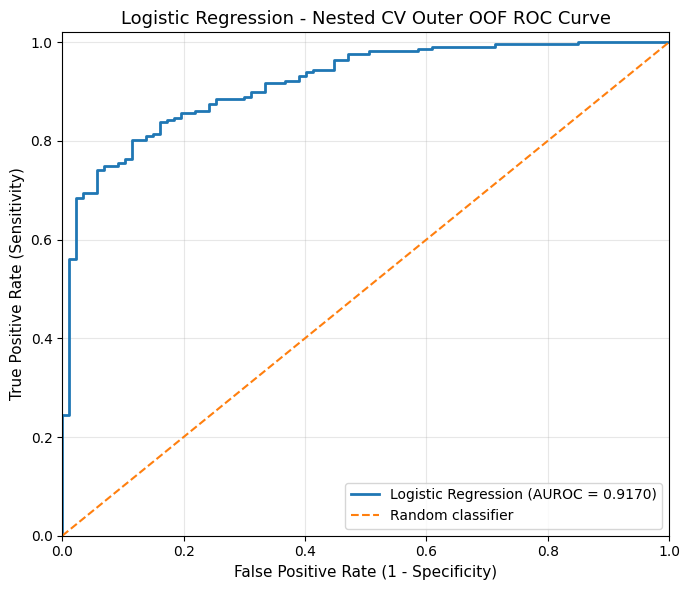


[저장 완료]
ROC Figure : /content/drive/MyDrive/clinical_cad/results/logistic_regression/figures/01_lr_nested_outer_oof_roc.png
ROC CSV    : /content/drive/MyDrive/clinical_cad/results/logistic_regression/tables/01_lr_nested_outer_oof_roc_curve.csv

✅ STEP 10-D-1 Final Nested CV ROC 시각화 완료


In [ ]:
from pathlib import Path

LR_RESULT_DIR = Path(
    "/content/drive/MyDrive/clinical_cad/results/logistic_regression"
)

LR_FIGURE_DIR = (
    LR_RESULT_DIR / "figures"
)

LR_TABLE_DIR = (
    LR_RESULT_DIR / "tables"
)


LR_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LR_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "LR 결과 폴더 :",
    LR_RESULT_DIR
)



# Final Nested Outer OOF ROC 계산
final_fpr, final_tpr, final_roc_thresholds = (
    roc_curve(
        y,
        lr_nested_oof_proba
    )
)


final_nested_auroc = roc_auc_score(
    y,
    lr_nested_oof_proba
)


print(
    f"Nested Outer OOF AUROC : "
    f"{final_nested_auroc:.4f}"
)



# ROC Curve 시각화
plt.figure(figsize=(7, 6))

# Logistic Regression ROC
plt.plot(
    final_fpr,
    final_tpr,
    linewidth=2,
    label=(
        "Logistic Regression "
        f"(AUROC = {final_nested_auroc:.4f})"
    )
)

# Random classifier 기준
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

# 그래프 설정
plt.xlabel(
    "False Positive Rate (1 - Specificity)",
    fontsize=11
)

plt.ylabel(
    "True Positive Rate (Sensitivity)",
    fontsize=11
)

plt.title(
    "Logistic Regression - Nested CV Outer OOF ROC Curve",
    fontsize=13
)

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1.02
)

plt.grid(
    alpha=0.3
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()


roc_figure_path = (
    LR_FIGURE_DIR /
    "01_lr_nested_outer_oof_roc.png"
)


plt.savefig(
    roc_figure_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()



# ROC Curve 원본 데이터 CSV 저장
roc_curve_df = pd.DataFrame({
    "FPR": final_fpr,
    "TPR": final_tpr,
    "Threshold": final_roc_thresholds
})


roc_csv_path = (
    LR_TABLE_DIR /
    "01_lr_nested_outer_oof_roc_curve.csv"
)


roc_curve_df.to_csv(
    roc_csv_path,
    index=False
)



# 저장 결과 확인
print("\n" + "=" * 90)
print("[저장 완료]")
print("=" * 90)

print(
    "ROC Figure :",
    roc_figure_path
)

print(
    "ROC CSV    :",
    roc_csv_path
)

print(
    "\n✅ STEP 10-D-1 "
    "Final Nested CV ROC 시각화 완료"
)

Nested Outer OOF AUPRC : 0.9647
CAD Prevalence         : 0.7129


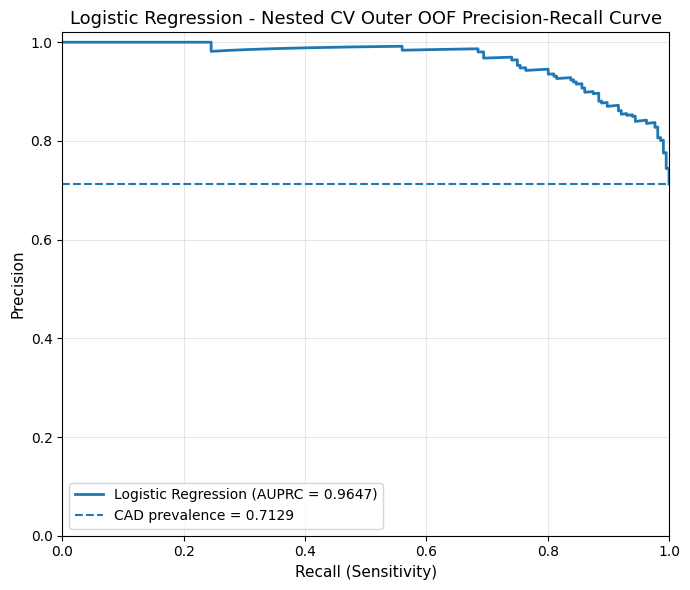


[저장 완료]
PR Figure : /content/drive/MyDrive/clinical_cad/results/logistic_regression/figures/02_lr_nested_outer_oof_pr_curve.png
PR CSV    : /content/drive/MyDrive/clinical_cad/results/logistic_regression/tables/02_lr_nested_outer_oof_pr_curve.csv

✅ STEP 10-D-2 Final Nested CV PR 시각화 완료


In [ ]:
# Precision-Recall Curve 계산
final_precision, final_recall, final_pr_thresholds = (
    precision_recall_curve(
        y,
        lr_nested_oof_proba
    )
)

# Final Nested Outer OOF AUPRC
final_nested_auprc = average_precision_score(
    y,
    lr_nested_oof_proba
)

# CAD prevalence 계산
cad_prevalence = y.mean()


print(
    f"Nested Outer OOF AUPRC : "
    f"{final_nested_auprc:.4f}"
)

print(
    f"CAD Prevalence         : "
    f"{cad_prevalence:.4f}"
)



# Precision-Recall Curve
plt.figure(
    figsize=(7, 6)
)


# Logistic Regression PR Curve
plt.plot(
    final_recall,
    final_precision,
    linewidth=2,
    label=(
        "Logistic Regression "
        f"(AUPRC = {final_nested_auprc:.4f})"
    )
)


# CAD prevalence 기준선
plt.axhline(
    y=cad_prevalence,
    linestyle="--",
    linewidth=1.5,
    label=(
        "CAD prevalence "
        f"= {cad_prevalence:.4f}"
    )
)



# 그래프 설정
plt.xlabel(
    "Recall (Sensitivity)",
    fontsize=11
)

plt.ylabel(
    "Precision",
    fontsize=11
)

plt.title(
    "Logistic Regression - Nested CV Outer OOF "
    "Precision-Recall Curve",
    fontsize=13
)

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1.02
)

plt.grid(
    alpha=0.3
)

plt.legend(
    loc="lower left"
)

plt.tight_layout()


# 저장
pr_figure_path = (
    LR_FIGURE_DIR /
    "02_lr_nested_outer_oof_pr_curve.png"
)


plt.savefig(
    pr_figure_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

pr_curve_df = pd.DataFrame({

    "Recall":
        final_recall,

    "Precision":
        final_precision,

    "Threshold":
        np.append(
            final_pr_thresholds,
            np.nan
        )
})


pr_csv_path = (
    LR_TABLE_DIR /
    "02_lr_nested_outer_oof_pr_curve.csv"
)


pr_curve_df.to_csv(
    pr_csv_path,
    index=False
)



# 7) 저장 결과 확인


print("\n" + "=" * 90)
print("[저장 완료]")
print("=" * 90)

print(
    "PR Figure :",
    pr_figure_path
)

print(
    "PR CSV    :",
    pr_csv_path
)


print(
    "\n✅ STEP 10-D-2 "
    "Final Nested CV PR 시각화 완료"
)

[1. Final Nested Outer OOF Confusion Matrix]
[[ 50  37]
 [ 12 204]]

TN : 50
FP : 37
FN : 12
TP : 204


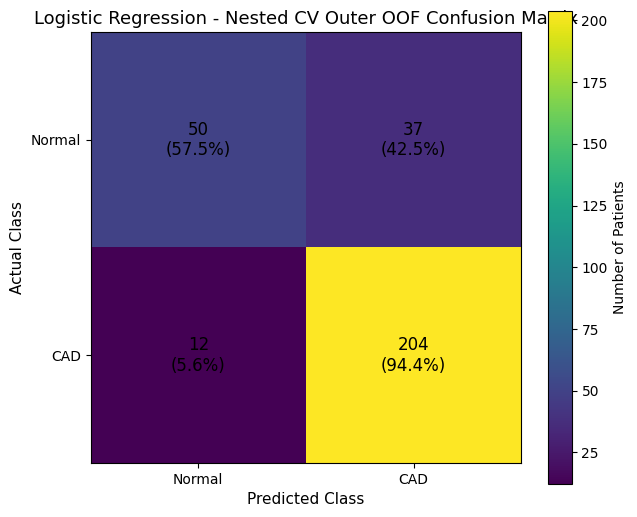


[2. Threshold-dependent Performance]


,TN,FP,FN,TP,Accuracy,Precision,Sensitivity,Specificity,NPV,F1
0,50,37,12,204,0.8383,0.8465,0.9444,0.5747,0.8065,0.8928



[저장 완료]
Confusion Matrix Figure : /content/drive/MyDrive/clinical_cad/results/logistic_regression/figures/03_lr_nested_outer_oof_confusion_matrix.png
Confusion Matrix CSV    : /content/drive/MyDrive/clinical_cad/results/logistic_regression/tables/03_lr_nested_outer_oof_confusion_matrix.csv
Classification Metrics : /content/drive/MyDrive/clinical_cad/results/logistic_regression/tables/04_lr_nested_outer_oof_classification_metrics.csv

✅ STEP 10-D-3 Final Nested CV Confusion Matrix 완료


In [ ]:
# ------------------------------------------------------------
# 1) Confusion Matrix 계산
# ------------------------------------------------------------

final_cm = confusion_matrix(
    y,
    lr_nested_oof_pred,
    labels=[0, 1]
)


final_tn, final_fp, final_fn, final_tp = (
    final_cm.ravel()
)


print("=" * 80)
print("[1. Final Nested Outer OOF Confusion Matrix]")
print("=" * 80)

print(final_cm)

print()

print(f"TN : {final_tn}")
print(f"FP : {final_fp}")
print(f"FN : {final_fn}")
print(f"TP : {final_tp}")


# ------------------------------------------------------------
# 2) 각 실제 Class 기준 비율 계산
# ------------------------------------------------------------
cm_row_percent = (
    final_cm
    / final_cm.sum(
        axis=1,
        keepdims=True
    )
    * 100
)


# ------------------------------------------------------------
# 3) annotation 문자열 생성
# ------------------------------------------------------------

annotation_matrix = np.empty(
    final_cm.shape,
    dtype=object
)


for i in range(
    final_cm.shape[0]
):

    for j in range(
        final_cm.shape[1]
    ):

        annotation_matrix[
            i,
            j
        ] = (
            f"{final_cm[i, j]}\n"
            f"({cm_row_percent[i, j]:.1f}%)"
        )


# ------------------------------------------------------------
# 4) Confusion Matrix 시각화
# ------------------------------------------------------------

plt.figure(
    figsize=(6.5, 5.5)
)


plt.imshow(
    final_cm,
    interpolation="nearest"
)


# ------------------------------------------------------------
# 축 설정
# ------------------------------------------------------------

class_names = [
    "Normal",
    "CAD"
]


plt.xticks(
    ticks=[0, 1],
    labels=class_names
)

plt.yticks(
    ticks=[0, 1],
    labels=class_names
)


plt.xlabel(
    "Predicted Class",
    fontsize=11
)

plt.ylabel(
    "Actual Class",
    fontsize=11
)


plt.title(
    "Logistic Regression - Nested CV Outer OOF "
    "Confusion Matrix",
    fontsize=13
)


# ------------------------------------------------------------
# 각 Cell에 Count + Percentage 표시
# ------------------------------------------------------------

threshold_for_text = (
    final_cm.max() / 2
)


for i in range(
    final_cm.shape[0]
):

    for j in range(
        final_cm.shape[1]
    ):

        plt.text(
            j,
            i,
            annotation_matrix[i, j],
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=12
        )


plt.colorbar(
    label="Number of Patients"
)

plt.tight_layout()


# ------------------------------------------------------------
# 5) PNG 저장
# ------------------------------------------------------------

cm_figure_path = (
    LR_FIGURE_DIR /
    "03_lr_nested_outer_oof_confusion_matrix.png"
)


plt.savefig(
    cm_figure_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ------------------------------------------------------------
# 6) Confusion Matrix CSV 저장
# ------------------------------------------------------------

cm_df = pd.DataFrame(
    final_cm,
    index=[
        "Actual_Normal",
        "Actual_CAD"
    ],
    columns=[
        "Predicted_Normal",
        "Predicted_CAD"
    ]
)


cm_csv_path = (
    LR_TABLE_DIR /
    "03_lr_nested_outer_oof_confusion_matrix.csv"
)


cm_df.to_csv(
    cm_csv_path
)


# ------------------------------------------------------------
# 7) 별도의 성능 요약 CSV도 저장
# ------------------------------------------------------------
final_classification_metrics_df = pd.DataFrame(
    [
        {
            "TN": final_tn,
            "FP": final_fp,
            "FN": final_fn,
            "TP": final_tp,

            "Accuracy":
                accuracy_score(
                    y,
                    lr_nested_oof_pred
                ),

            "Precision":
                precision_score(
                    y,
                    lr_nested_oof_pred,
                    zero_division=0
                ),

            "Sensitivity":
                recall_score(
                    y,
                    lr_nested_oof_pred
                ),

            "Specificity":
                final_tn
                / (final_tn + final_fp),

            "NPV":
                final_tn
                / (final_tn + final_fn),

            "F1":
                f1_score(
                    y,
                    lr_nested_oof_pred,
                    zero_division=0
                )
        }
    ]
)


classification_metrics_csv_path = (
    LR_TABLE_DIR /
    "04_lr_nested_outer_oof_classification_metrics.csv"
)


final_classification_metrics_df.to_csv(
    classification_metrics_csv_path,
    index=False
)


print("\n" + "=" * 80)
print("[2. Threshold-dependent Performance]")
print("=" * 80)

display(
    final_classification_metrics_df.round(4)
)


print("\n" + "=" * 80)
print("[저장 완료]")
print("=" * 80)

print(
    "Confusion Matrix Figure :",
    cm_figure_path
)

print(
    "Confusion Matrix CSV    :",
    cm_csv_path
)

print(
    "Classification Metrics :",
    classification_metrics_csv_path
)


print(
    "\n✅ STEP 10-D-3 "
    "Final Nested CV Confusion Matrix 완료"
)

[1. Fold별 Optimized Threshold]


,Fold,Threshold,Inner Sensitivity,Inner Specificity
0,1,0.3018,0.9536,0.5128
1,2,0.3095,0.9536,0.5769
2,3,0.4557,0.9536,0.6538
3,4,0.4104,0.9536,0.5696
4,5,0.3111,0.9536,0.5949
5,6,0.2791,0.9536,0.5823
6,7,0.2937,0.9538,0.5385
7,8,0.2499,0.9538,0.5385
8,9,0.4609,0.9538,0.6795
9,10,0.3767,0.9538,0.5385



[2. Threshold Summary]


,Mean,Median,Std,Min,Max,Default Threshold
0,0.3449,0.3103,0.0755,0.2499,0.4609,0.5


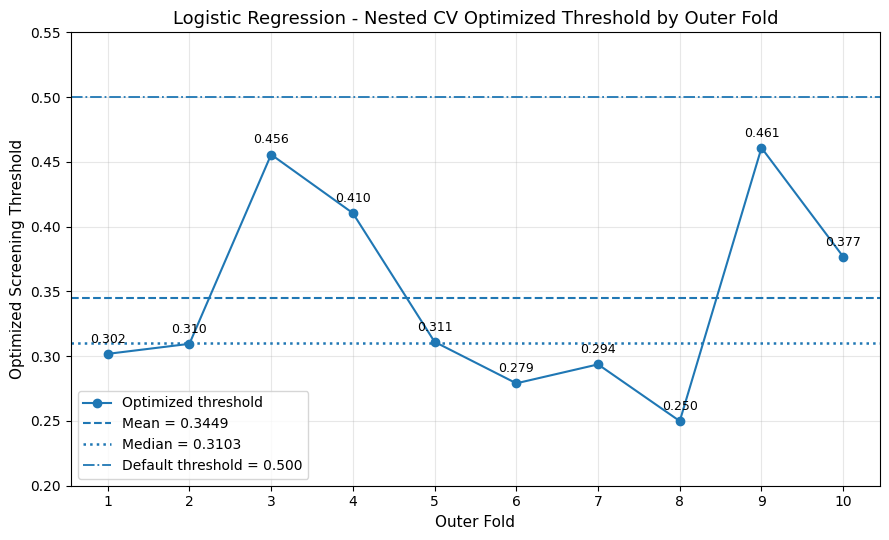


[저장 완료]
Threshold Figure : /content/drive/MyDrive/clinical_cad/results/logistic_regression/figures/04_lr_nested_threshold_by_fold.png
Threshold CSV    : /content/drive/MyDrive/clinical_cad/results/logistic_regression/tables/05_lr_nested_threshold_by_fold.csv
Summary CSV      : /content/drive/MyDrive/clinical_cad/results/logistic_regression/tables/06_lr_nested_threshold_summary.csv

✅ STEP 10-D-4 Nested CV Threshold Distribution 완료


In [ ]:
# ------------------------------------------------------------
# 1) Fold별 Threshold 데이터 확인
# ------------------------------------------------------------

threshold_plot_df = (
    lr_final_selection_df[
        [
            "Fold",
            "Threshold",
            "Inner Sensitivity",
            "Inner Specificity"
        ]
    ]
    .copy()
)


print("=" * 95)
print("[1. Fold별 Optimized Threshold]")
print("=" * 95)

display(
    threshold_plot_df.round(4)
)


# ------------------------------------------------------------
# 2) Threshold 요약 통계
# ------------------------------------------------------------

threshold_mean = (
    threshold_plot_df[
        "Threshold"
    ].mean()
)

threshold_median = (
    threshold_plot_df[
        "Threshold"
    ].median()
)

threshold_std = (
    threshold_plot_df[
        "Threshold"
    ].std(ddof=1)
)

threshold_min = (
    threshold_plot_df[
        "Threshold"
    ].min()
)

threshold_max = (
    threshold_plot_df[
        "Threshold"
    ].max()
)


threshold_summary_df = pd.DataFrame(
    [
        {
            "Mean":
                threshold_mean,

            "Median":
                threshold_median,

            "Std":
                threshold_std,

            "Min":
                threshold_min,

            "Max":
                threshold_max,

            "Default Threshold":
                0.500
        }
    ]
)


print("\n" + "=" * 95)
print("[2. Threshold Summary]")
print("=" * 95)

display(
    threshold_summary_df.round(4)
)


# ------------------------------------------------------------
# 3) Fold별 Threshold 시각화
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5.5)
)


# Fold별 Threshold
plt.plot(
    threshold_plot_df["Fold"],
    threshold_plot_df["Threshold"],
    marker="o",
    linewidth=1.5,
    label="Optimized threshold"
)


# ------------------------------------------------------------
# Mean Threshold
# ------------------------------------------------------------

plt.axhline(
    y=threshold_mean,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Mean = "
        f"{threshold_mean:.4f}"
    )
)


# ------------------------------------------------------------
# Median Threshold
# ------------------------------------------------------------

plt.axhline(
    y=threshold_median,
    linestyle=":",
    linewidth=1.8,
    label=(
        f"Median = "
        f"{threshold_median:.4f}"
    )
)


# ------------------------------------------------------------
# 기본 Threshold = 0.5
# ------------------------------------------------------------
plt.axhline(
    y=0.500,
    linestyle="-.",
    linewidth=1.3,
    label="Default threshold = 0.500"
)


# ------------------------------------------------------------
# 각 Fold Point에 실제 Threshold 값 표시
# ------------------------------------------------------------

for _, row in threshold_plot_df.iterrows():

    plt.annotate(
        f"{row['Threshold']:.3f}",
        (
            row["Fold"],
            row["Threshold"]
        ),
        xytext=(0, 8),
        textcoords="offset points",
        horizontalalignment="center",
        fontsize=9
    )


# ------------------------------------------------------------
# 그래프 설정
# ------------------------------------------------------------

plt.xticks(
    threshold_plot_df["Fold"]
)

plt.xlabel(
    "Outer Fold",
    fontsize=11
)

plt.ylabel(
    "Optimized Screening Threshold",
    fontsize=11
)

plt.title(
    "Logistic Regression - "
    "Nested CV Optimized Threshold by Outer Fold",
    fontsize=13
)


# Threshold 범위를 조금 넉넉하게 표시
plt.ylim(
    0.20,
    0.55
)


plt.grid(
    alpha=0.3
)

plt.legend(
    loc="best"
)

plt.tight_layout()


# ------------------------------------------------------------
# 4) Figure 저장
# ------------------------------------------------------------

threshold_figure_path = (
    LR_FIGURE_DIR /
    "04_lr_nested_threshold_by_fold.png"
)


plt.savefig(
    threshold_figure_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ------------------------------------------------------------
# 5) Fold별 Threshold CSV 저장
# ------------------------------------------------------------

threshold_csv_path = (
    LR_TABLE_DIR /
    "05_lr_nested_threshold_by_fold.csv"
)


threshold_plot_df.to_csv(
    threshold_csv_path,
    index=False
)


# ------------------------------------------------------------
# 6) Threshold Summary CSV 저장
# ------------------------------------------------------------

threshold_summary_csv_path = (
    LR_TABLE_DIR /
    "06_lr_nested_threshold_summary.csv"
)


threshold_summary_df.to_csv(
    threshold_summary_csv_path,
    index=False
)


# ------------------------------------------------------------
# 7) 저장 결과 확인
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("[저장 완료]")
print("=" * 95)

print(
    "Threshold Figure :",
    threshold_figure_path
)

print(
    "Threshold CSV    :",
    threshold_csv_path
)

print(
    "Summary CSV      :",
    threshold_summary_csv_path
)


print(
    "\n✅ STEP 10-D-4 "
    "Nested CV Threshold Distribution 완료"
)

# Logistic Regression Calibration

In [ ]:
# 기존 Nested Outer OOF Probability 변수명 자동 찾기
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

candidate_results = []

# globals()를 실행 도중 변경하지 않도록
# list()로 복사해서 확인
for var_name, var_value in list(globals().items()):

    # 내부 시스템 변수 등 제외
    if var_name.startswith("_"):
        continue

    try:
        arr = np.asarray(var_value)

        # ----------------------------------------------------
        # OOF probability가 될 가능성이 있는 조건
        #
        # 1. 1차원
        # 2. 환자 수와 동일
        # 3. numeric
        # 4. 모든 값이 0~1
        # ----------------------------------------------------

        if arr.ndim != 1:
            continue

        if len(arr) != len(y):
            continue

        if not np.issubdtype(arr.dtype, np.number):
            continue

        if np.any(~np.isfinite(arr)):
            continue

        if np.min(arr) < 0 or np.max(arr) > 1:
            continue

        # 실제 y 자체(0/1 label)는 제외
        if len(np.unique(arr)) <= 2:
            continue

        auc = roc_auc_score(
            y,
            arr
        )

        ap = average_precision_score(
            y,
            arr
        )

        candidate_results.append(
            {
                "Variable Name": var_name,
                "Shape": arr.shape,
                "Min": np.min(arr),
                "Max": np.max(arr),
                "AUROC": auc,
                "AUPRC": ap
            }
        )

    except Exception:
        # probability 후보가 아니면 그냥 건너뜀
        pass


candidate_df = pd.DataFrame(
    candidate_results
)


# ------------------------------------------------------------
# Nested Final 결과
#
# AUROC = 0.9170
# AUPRC = 0.9647
#
# 와 가까운 순으로 정렬
# ------------------------------------------------------------

if len(candidate_df) > 0:

    candidate_df["Distance to Final Nested"] = (
        abs(candidate_df["AUROC"] - 0.9170)
        +
        abs(candidate_df["AUPRC"] - 0.9647)
    )

    candidate_df = (
        candidate_df
        .sort_values(
            "Distance to Final Nested"
        )
        .reset_index(drop=True)
    )


print("=" * 95)
print("[현재 Colab에 존재하는 OOF Probability 후보]")
print("=" * 95)

display(
    candidate_df.round(6)
)


print("\n" + "=" * 95)
print("[Final Nested CV와 가장 가까운 변수]")
print("=" * 95)

if len(candidate_df) > 0:

    best_candidate = candidate_df.iloc[0]

    print(
        "Variable Name :",
        best_candidate["Variable Name"]
    )

    print(
        "AUROC         :",
        round(
            best_candidate["AUROC"],
            4
        )
    )

    print(
        "AUPRC         :",
        round(
            best_candidate["AUPRC"],
            4
        )
    )

else:

    print(
        "현재 메모리에서 probability 후보를 찾지 못했습니다."
    )

[현재 Colab에 존재하는 OOF Probability 후보]


,Variable Name,Shape,Min,Max,AUROC,AUPRC,Distance to Final Nested
0,lr_tuned_oof_proba,"(303,)",0.003658,0.999996,0.917039,0.964672,0.000067
1,lr_nested_oof_proba,"(303,)",0.003658,0.999996,0.917039,0.964672,0.000067
2,lr_oof_proba,"(303,)",0.001235,0.999997,0.923585,0.968159,0.010044
3,pr_thresholds,"(303,)",0.001235,0.999997,0.355258,0.619067,0.907375
4,final_pr_thresholds,"(303,)",0.003658,0.999996,0.355258,0.619067,0.907375



[Final Nested CV와 가장 가까운 변수]
Variable Name : lr_tuned_oof_proba
AUROC         : 0.917
AUPRC         : 0.9647


[0. OOF Probability 확인]
lr_tuned_oof_proba와 동일 : True
Number of Patients         : 303
Probability Min            : 0.003658
Probability Max            : 0.999996

[1. Final Nested OOF Calibration Metrics]


,Metric,Value
0,CAD Prevalence,0.712871
1,Mean Predicted Probability,0.699092
2,Brier Score,0.104617
3,Baseline Brier Score,0.204686
4,Brier Skill Score,0.488890
5,Log Loss,0.324486
6,ECE (10 Quantile Bins),0.032996



[2. Quantile Bin별 Calibration]


,Bin,N,Mean Predicted Probability,Actual CAD Rate,Absolute Calibration Gap
0,1,31,0.0944,0.0645,0.0299
1,2,30,0.2436,0.3333,0.0897
2,3,30,0.4354,0.4667,0.0312
3,4,30,0.6388,0.6000,0.0388
4,5,31,0.7773,0.7742,0.0031
5,6,30,0.8907,0.9333,0.0427
6,7,30,0.9535,1.0000,0.0465
7,8,30,0.9753,1.0000,0.0247
8,9,30,0.9908,0.9667,0.0241
9,10,31,0.9986,1.0000,0.0014


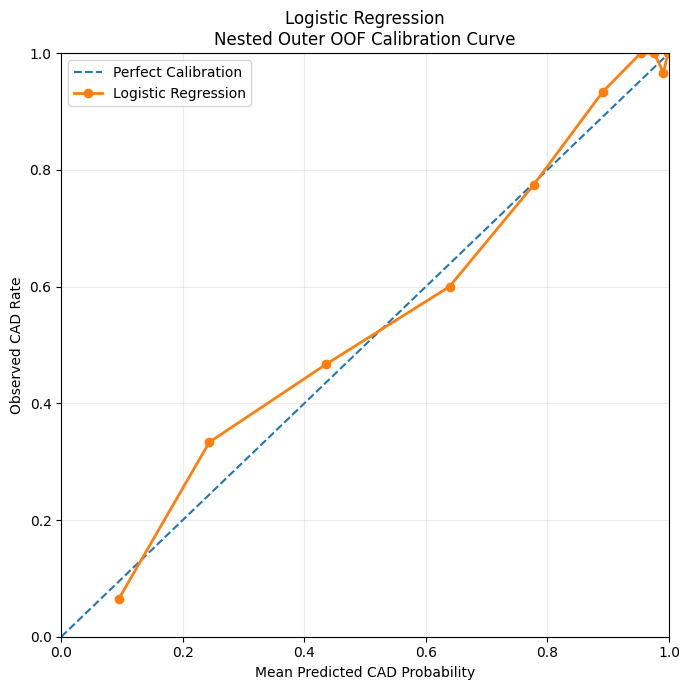


[저장 완료]
Calibration Figure : /content/drive/MyDrive/clinical_cad/results/logistic_regression/figures/05_lr_nested_oof_calibration_curve.png
Calibration Metrics: /content/drive/MyDrive/clinical_cad/results/logistic_regression/tables/07_lr_nested_oof_calibration_metrics.csv
Calibration Bins   : /content/drive/MyDrive/clinical_cad/results/logistic_regression/tables/08_lr_nested_oof_calibration_bins.csv

✅ STEP 10-D-5 Final Nested OOF Calibration 완료


In [ ]:
# ============================================================
# Logistic Regression
# Final Nested Outer OOF Probability Calibration 평가
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    brier_score_loss,
    log_loss
)

from pathlib import Path


# ============================================================
# 1. Final Nested OOF probability 확인
# ============================================================

final_oof_proba = np.asarray(
    lr_nested_oof_proba,
    dtype=float
)

y_true = np.asarray(
    y,
    dtype=int
)


# ------------------------------------------------------------
# 기본 안전성 검사
# ------------------------------------------------------------

assert len(final_oof_proba) == len(y_true), (
    "OOF probability와 y의 길이가 다릅니다."
)

assert np.all(
    np.isfinite(final_oof_proba)
), "OOF probability에 NaN 또는 inf가 있습니다."

assert (
    final_oof_proba.min() >= 0
    and
    final_oof_proba.max() <= 1
), "Probability가 0~1 범위를 벗어났습니다."


# ------------------------------------------------------------
# lr_tuned_oof_proba와 같은 값인지 확인
# ------------------------------------------------------------

same_probability = np.allclose(
    np.asarray(lr_tuned_oof_proba),
    final_oof_proba
)


print("=" * 95)
print("[0. OOF Probability 확인]")
print("=" * 95)

print(
    "lr_tuned_oof_proba와 동일 :",
    same_probability
)

print(
    "Number of Patients         :",
    len(final_oof_proba)
)

print(
    "Probability Min            :",
    round(final_oof_proba.min(), 6)
)

print(
    "Probability Max            :",
    round(final_oof_proba.max(), 6)
)


# ============================================================
# 2. 전체 Calibration 지표
# ============================================================

prevalence = y_true.mean()

mean_predicted_probability = final_oof_proba.mean()


# ------------------------------------------------------------
# Brier Score
# 평균적인 확률 예측 오차
# 0에 가까울수록 좋음
# ------------------------------------------------------------

brier = brier_score_loss(
    y_true,
    final_oof_proba
)



ll = log_loss(
    y_true,
    final_oof_proba
)


# Reference Brier Score
baseline_proba = np.full(
    len(y_true),
    prevalence
)

baseline_brier = brier_score_loss(
    y_true,
    baseline_proba
)


# ------------------------------------------------------------
# Brier Skill Score
# > 0 : prevalence만 예측하는 모델보다 좋음
# = 0 : 동일
# < 0 : 오히려 나쁨
# ------------------------------------------------------------

brier_skill_score = (
    1
    -
    brier / baseline_brier
)


# ============================================================
# 3. Calibration Curve
# ============================================================

n_bins = 10

fraction_of_positives, mean_predicted_value = (
    calibration_curve(
        y_true,
        final_oof_proba,
        n_bins=n_bins,
        strategy="quantile"
    )
)


# Expected Calibration Error

quantile_edges = np.quantile(
    final_oof_proba,
    np.linspace(
        0,
        1,
        n_bins + 1
    )
)

# 양 끝 값을 안전하게 확장
quantile_edges[0] = -np.inf
quantile_edges[-1] = np.inf


bin_indices = np.digitize(
    final_oof_proba,
    quantile_edges[1:-1],
    right=True
)


calibration_rows = []

ece = 0.0


for bin_idx in range(n_bins):

    mask = (
        bin_indices == bin_idx
    )

    n = mask.sum()

    if n == 0:
        continue

    bin_pred_mean = (
        final_oof_proba[mask].mean()
    )

    bin_actual_rate = (
        y_true[mask].mean()
    )

    abs_gap = abs(
        bin_actual_rate
        -
        bin_pred_mean
    )

    weight = (
        n / len(y_true)
    )

    ece += (
        weight * abs_gap
    )

    calibration_rows.append(
        {
            "Bin": bin_idx + 1,
            "N": n,
            "Mean Predicted Probability":
                bin_pred_mean,
            "Actual CAD Rate":
                bin_actual_rate,
            "Absolute Calibration Gap":
                abs_gap
        }
    )


calibration_df = pd.DataFrame(
    calibration_rows
)


# ============================================================
# 5. 지표 출력
# ============================================================

metrics_df = pd.DataFrame(
    {
        "Metric": [
            "CAD Prevalence",
            "Mean Predicted Probability",
            "Brier Score",
            "Baseline Brier Score",
            "Brier Skill Score",
            "Log Loss",
            "ECE (10 Quantile Bins)"
        ],
        "Value": [
            prevalence,
            mean_predicted_probability,
            brier,
            baseline_brier,
            brier_skill_score,
            ll,
            ece
        ]
    }
)


print(
    "\n" + "=" * 95
)

print(
    "[1. Final Nested OOF Calibration Metrics]"
)

print(
    "=" * 95
)

display(
    metrics_df.round(6)
)


print(
    "\n" + "=" * 95
)

print(
    "[2. Quantile Bin별 Calibration]"
)

print(
    "=" * 95
)

display(
    calibration_df.round(4)
)



# 6. Reliability Diagram

fig, ax = plt.subplots(
    figsize=(7, 7)
)


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)


ax.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker="o",
    linewidth=2,
    label="Logistic Regression"
)


ax.set_xlabel(
    "Mean Predicted CAD Probability"
)

ax.set_ylabel(
    "Observed CAD Rate"
)

ax.set_title(
    "Logistic Regression\n"
    "Nested Outer OOF Calibration Curve"
)

ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()



# 7. 결과 저장

RESULT_DIR = Path(
    "/content/drive/MyDrive/clinical_cad/results/logistic_regression"
)

FIGURE_DIR = (
    RESULT_DIR / "figures"
)

TABLE_DIR = (
    RESULT_DIR / "tables"
)


FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


calibration_figure_path = (
    FIGURE_DIR
    /
    "05_lr_nested_oof_calibration_curve.png"
)

calibration_metrics_path = (
    TABLE_DIR
    /
    "07_lr_nested_oof_calibration_metrics.csv"
)

calibration_bins_path = (
    TABLE_DIR
    /
    "08_lr_nested_oof_calibration_bins.csv"
)


fig.savefig(
    calibration_figure_path,
    dpi=300,
    bbox_inches="tight"
)


metrics_df.to_csv(
    calibration_metrics_path,
    index=False
)


calibration_df.to_csv(
    calibration_bins_path,
    index=False
)


plt.show()


print(
    "\n" + "=" * 95
)

print(
    "[저장 완료]"
)

print(
    "=" * 95
)

print(
    "Calibration Figure :",
    calibration_figure_path
)

print(
    "Calibration Metrics:",
    calibration_metrics_path
)

print(
    "Calibration Bins   :",
    calibration_bins_path
)


print(
    "\n✅ STEP 10-D-5 Final Nested OOF Calibration 완료"
)

In [ ]:
# ============================================================
# Logistic Regression
# 전체 303명 데이터를 이용한 Final Hyperparameter 선택
# ============================================================


import pandas as pd

from pathlib import Path

from sklearn.base import clone
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


# ============================================================
# 1. Final Logistic Regression Pipeline
# ============================================================

lr_final_search_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),

        (
            "model",
            LogisticRegression(
                solver="liblinear",
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)


# ============================================================
# 2. Hyperparameter Search Space
# ============================================================

final_lr_param_grid = {
    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "model__penalty": [
        "l1",
        "l2"
    ],

    "model__class_weight": [
        None,
        "balanced"
    ]
}


# ============================================================
# 3. Final Model Selection CV
# ============================================================

final_selection_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ============================================================
# 4. Grid Search
# ============================================================

lr_final_grid = GridSearchCV(
    estimator=lr_final_search_pipeline,

    param_grid=final_lr_param_grid,

    scoring="roc_auc",

    cv=final_selection_cv,

    refit=True,

    n_jobs=-1,

    return_train_score=True
)


# ============================================================
# 5. 전체 303명으로 Grid Search 실행
# ============================================================

lr_final_grid.fit(
    X_baseline,
    y
)


# ============================================================
# 6. Best Parameter 출력
# ============================================================

print("=" * 95)
print("[1. Final Logistic Regression Hyperparameter]")
print("=" * 95)

print(
    "Best C            :",
    lr_final_grid.best_params_[
        "model__C"
    ]
)

print(
    "Best Penalty      :",
    lr_final_grid.best_params_[
        "model__penalty"
    ]
)

print(
    "Best Class Weight :",
    lr_final_grid.best_params_[
        "model__class_weight"
    ]
)

print(
    "Best CV AUROC     :",
    round(
        lr_final_grid.best_score_,
        6
    )
)


# ============================================================
# 7. 전체 Grid Search 결과 정리
# ============================================================

final_grid_results = pd.DataFrame(
    lr_final_grid.cv_results_
)


final_grid_table = (
    final_grid_results[
        [
            "param_model__C",
            "param_model__penalty",
            "param_model__class_weight",

            "mean_train_score",
            "std_train_score",

            "mean_test_score",
            "std_test_score",

            "rank_test_score"
        ]
    ]
    .sort_values(
        "rank_test_score"
    )
    .reset_index(
        drop=True
    )
)


final_grid_table.columns = [
    "C",
    "Penalty",
    "Class Weight",

    "Train AUROC Mean",
    "Train AUROC SD",

    "CV AUROC Mean",
    "CV AUROC SD",

    "Rank"
]


print(
    "\n" + "=" * 95
)

print(
    "[2. 전체 Grid Search 결과]"
)

print(
    "=" * 95
)


display(
    final_grid_table.round(6)
)


# ============================================================
# 8. Best Parameter 저장
# ============================================================

RESULT_DIR = Path(
    "/content/drive/MyDrive/clinical_cad/results/logistic_regression"
)

TABLE_DIR = (
    RESULT_DIR / "tables"
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


final_grid_result_path = (
    TABLE_DIR
    /
    "09_lr_final_grid_search_results.csv"
)


final_best_param_path = (
    TABLE_DIR
    /
    "10_lr_final_best_hyperparameters.csv"
)


final_grid_table.to_csv(
    final_grid_result_path,
    index=False
)


final_best_param_df = pd.DataFrame(
    [
        {
            "C":
                lr_final_grid.best_params_[
                    "model__C"
                ],

            "Penalty":
                lr_final_grid.best_params_[
                    "model__penalty"
                ],

            "Class Weight":
                lr_final_grid.best_params_[
                    "model__class_weight"
                ],

            "Selection Metric":
                "AUROC",

            "5-Fold CV AUROC":
                lr_final_grid.best_score_
        }
    ]
)


final_best_param_df.to_csv(
    final_best_param_path,
    index=False
)


print(
    "\n" + "=" * 95
)

print(
    "[저장 완료]"
)

print(
    "=" * 95
)

print(
    "Grid Search Results :",
    final_grid_result_path
)

print(
    "Best Hyperparameters:",
    final_best_param_path
)


print(
    "\n✅ STEP 10-E-1 Final LR Hyperparameter Selection 완료"
)

print(
    "\n※ 주의:"
)

print(
    "위 CV AUROC는 Final parameter를 고르기 위한 값이며,"
)

print(
    "최종 보고 성능으로 사용하지 않습니다."
)

print(
    "보고 성능은 Nested CV Outer validation 결과를 사용합니다."
)

[1. Final Logistic Regression Hyperparameter]
Best C            : 0.1
Best Penalty      : l2
Best Class Weight : None
Best CV AUROC     : 0.927113

[2. 전체 Grid Search 결과]


,C,Penalty,Class Weight,Train AUROC Mean,Train AUROC SD,CV AUROC Mean,CV AUROC SD,Rank
0,0.10,l2,None,0.964214,0.007153,0.927113,0.032988,1
1,1.00,l1,None,0.974275,0.005802,0.926837,0.041447,2
2,1.00,l2,None,0.979736,0.004892,0.925517,0.035344,3
3,1.00,l2,balanced,0.979552,0.005020,0.924368,0.039320,4
4,0.10,l2,balanced,0.964398,0.007150,0.923203,0.037960,5
5,1.00,l1,balanced,0.974443,0.005634,0.922660,0.049799,6
6,10.00,l2,None,0.989318,0.003983,0.916605,0.038529,7
7,0.10,l1,balanced,0.935277,0.012534,0.915625,0.056239,8
8,10.00,l2,balanced,0.988839,0.004470,0.913882,0.039902,9
9,0.01,l2,None,0.941235,0.009491,0.909898,0.029569,10



[저장 완료]
Grid Search Results : /content/drive/MyDrive/clinical_cad/results/logistic_regression/tables/09_lr_final_grid_search_results.csv
Best Hyperparameters: /content/drive/MyDrive/clinical_cad/results/logistic_regression/tables/10_lr_final_best_hyperparameters.csv

✅ STEP 10-E-1 Final LR Hyperparameter Selection 완료

※ 주의:
위 CV AUROC는 Final parameter를 고르기 위한 값이며,
최종 보고 성능으로 사용하지 않습니다.
보고 성능은 Nested CV Outer validation 결과를 사용합니다.


In [ ]:
# =============================================================================
# Final Logistic Regression Candidate
# Fixed Hyperparameter 기반 OOF Probability 생성

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score


# -----------------------------------------------------------------------------
# 1. 확정된 Final LR Hyperparameter
# -----------------------------------------------------------------------------
FINAL_LR_C = 0.1
FINAL_LR_PENALTY = "l2"
FINAL_LR_CLASS_WEIGHT = None


# -----------------------------------------------------------------------------
# 2. Final LR Candidate Pipeline 정의
# -----------------------------------------------------------------------------
lr_final_candidate = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),

        (
            "model",
            LogisticRegression(
                penalty=FINAL_LR_PENALTY,
                C=FINAL_LR_C,
                solver="liblinear",
                class_weight=FINAL_LR_CLASS_WEIGHT,
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)


# -----------------------------------------------------------------------------
# 3. Final Threshold 결정용 Stratified 10-Fold CV
# -----------------------------------------------------------------------------
lr_final_threshold_cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)


# -----------------------------------------------------------------------------
# 4. OOF Probability 생성
# -----------------------------------------------------------------------------
lr_final_oof_proba = cross_val_predict(
    estimator=lr_final_candidate,
    X=X_baseline,
    y=y,
    cv=lr_final_threshold_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


# -----------------------------------------------------------------------------
# 5. 기본 검증
# -----------------------------------------------------------------------------
assert len(lr_final_oof_proba) == len(y), \
    "OOF probability 수와 환자 수가 다릅니다."

assert np.isnan(lr_final_oof_proba).sum() == 0, \
    "OOF probability에 NaN이 존재합니다."

assert np.all(
    (lr_final_oof_proba >= 0) &
    (lr_final_oof_proba <= 1)
), "Probability가 0~1 범위를 벗어났습니다."


# -----------------------------------------------------------------------------
# 6. Sanity Check용 AUROC / AUPRC
# -----------------------------------------------------------------------------
lr_final_oof_auroc = roc_auc_score(
    y,
    lr_final_oof_proba
)

lr_final_oof_auprc = average_precision_score(
    y,
    lr_final_oof_proba
)


# -----------------------------------------------------------------------------
# 7. 환자별 OOF Probability Table 생성
# -----------------------------------------------------------------------------
lr_final_oof_df = pd.DataFrame({
    "Patient_Index": X_baseline.index,
    "True_Label": np.asarray(y),
    "Final_LR_OOF_Probability": lr_final_oof_proba
})


# -----------------------------------------------------------------------------
# 8. 결과 출력
# -----------------------------------------------------------------------------
print("=" * 95)
print("[1. Final LR Candidate]")
print("=" * 95)

print(f"C            : {FINAL_LR_C}")
print(f"Penalty      : {FINAL_LR_PENALTY}")
print(f"Class Weight : {FINAL_LR_CLASS_WEIGHT}")
print()


print("=" * 95)
print("[2. Final LR OOF Probability]")
print("=" * 95)

print(f"Number of Patients : {len(lr_final_oof_proba)}")
print(f"Probability Min    : {lr_final_oof_proba.min():.6f}")
print(f"Probability Max    : {lr_final_oof_proba.max():.6f}")
print(f"Probability Mean   : {lr_final_oof_proba.mean():.6f}")
print()


print("=" * 95)
print("[3. Sanity Check Metrics - 최종 보고 성능 아님]")
print("=" * 95)

print(f"OOF AUROC : {lr_final_oof_auroc:.6f}")
print(f"OOF AUPRC : {lr_final_oof_auprc:.6f}")
print()


print("=" * 95)
print("[4. OOF Probability Sample]")
print("=" * 95)

display(lr_final_oof_df.head(10))


# -----------------------------------------------------------------------------
# 9. CSV 저장
# -----------------------------------------------------------------------------
lr_final_oof_path = (
    "/content/drive/MyDrive/clinical_cad/results/"
    "logistic_regression/tables/"
    "11_lr_final_candidate_oof_probability.csv"
)

lr_final_oof_df.to_csv(
    lr_final_oof_path,
    index=False
)


print()
print("=" * 95)
print("[저장 완료]")
print("=" * 95)

print(
    "Final LR OOF Probability :",
    lr_final_oof_path
)

print()
print("✅ STEP 10-E-2 Final LR OOF Probability 생성 완료")
print()
print(
    "※ 주의: 위 OOF AUROC / AUPRC는 "
    "Final Threshold 결정 과정의 참고값이며,"
)
print(
    "   최종 보고 성능은 Nested CV Outer Validation 결과를 사용합니다."
)

[1. Final LR Candidate]
C            : 0.1
Penalty      : l2
Class Weight : None

[2. Final LR OOF Probability]
Number of Patients : 303
Probability Min    : 0.058512
Probability Max    : 0.998574
Probability Mean   : 0.705898

[3. Sanity Check Metrics - 최종 보고 성능 아님]
OOF AUROC : 0.925979
OOF AUPRC : 0.968696

[4. OOF Probability Sample]


,Patient_Index,True_Label,Final_LR_OOF_Probability
0,0,1,0.722705
1,1,1,0.996220
2,2,1,0.927862
3,3,0,0.492144
4,4,0,0.162477
5,5,1,0.725668
6,6,1,0.962615
7,7,1,0.989052
8,8,0,0.058512
9,9,1,0.888078



[저장 완료]
Final LR OOF Probability : /content/drive/MyDrive/clinical_cad/results/logistic_regression/tables/11_lr_final_candidate_oof_probability.csv

✅ STEP 10-E-2 Final LR OOF Probability 생성 완료

※ 주의: 위 OOF AUROC / AUPRC는 Final Threshold 결정 과정의 참고값이며,
   최종 보고 성능은 Nested CV Outer Validation 결과를 사용합니다.


In [ ]:
# =============================================================================
# Final Logistic Regression
# Single Operational Threshold Selection
# =============================================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# -----------------------------------------------------------------------------
# 1. Screening Sensitivity Target
# CAD 환자를 가능한 한 놓치지 않는 방향으로 threshold를 결정한다.
# -----------------------------------------------------------------------------
FINAL_LR_SENSITIVITY_TARGET = 0.95


# -----------------------------------------------------------------------------
# 2. 입력 데이터 확인
# -----------------------------------------------------------------------------
y_true = np.asarray(y).astype(int)
y_prob = np.asarray(lr_final_oof_proba).astype(float)

assert len(y_true) == len(y_prob), \
    "y와 OOF probability 길이가 다릅니다."

assert np.isnan(y_prob).sum() == 0, \
    "OOF probability에 NaN이 있습니다."


# -----------------------------------------------------------------------------
# 3. 가능한 모든 threshold 후보 생성
# -----------------------------------------------------------------------------
candidate_thresholds = np.sort(
    np.unique(y_prob)
)


threshold_results = []


# -----------------------------------------------------------------------------
# 4. 각 threshold에서 Screening 성능 계산
# -----------------------------------------------------------------------------
for threshold in candidate_thresholds:

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    # CAD Sensitivity
    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    # Normal Specificity
    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )

    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )

    accuracy = (
        (tp + tn) /
        (tp + tn + fp + fn)
    )

    f1 = (
        2 * precision * sensitivity /
        (precision + sensitivity)
        if (
            precision + sensitivity > 0
        )
        else np.nan
    )

    threshold_results.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "NPV": npv,
        "Accuracy": accuracy,
        "F1": f1
    })


threshold_results_df = pd.DataFrame(
    threshold_results
)


# -----------------------------------------------------------------------------
# 5. Sensitivity >= 95% 조건을 만족하는 후보만 남김
# -----------------------------------------------------------------------------
eligible_thresholds_df = (
    threshold_results_df[
        threshold_results_df[
            "Sensitivity"
        ] >= FINAL_LR_SENSITIVITY_TARGET
    ]
    .copy()
)


assert len(eligible_thresholds_df) > 0, \
    "Sensitivity >= 95%를 만족하는 threshold가 없습니다."


# -----------------------------------------------------------------------------
# 6. Final Threshold 선택
# -----------------------------------------------------------------------------
eligible_thresholds_df = (
    eligible_thresholds_df
    .sort_values(
        by=[
            "Specificity",
            "Threshold"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)


final_lr_threshold_row = (
    eligible_thresholds_df.iloc[0]
)


FINAL_LR_THRESHOLD = float(
    final_lr_threshold_row[
        "Threshold"
    ]
)


# -----------------------------------------------------------------------------
# 7. 선택된 threshold 기준 OOF prediction 생성
# -----------------------------------------------------------------------------
lr_final_oof_pred = (
    y_prob >= FINAL_LR_THRESHOLD
).astype(int)


tn, fp, fn, tp = confusion_matrix(
    y_true,
    lr_final_oof_pred,
    labels=[0, 1]
).ravel()


# -----------------------------------------------------------------------------
# 8. Default Threshold 0.5와 비교
# -----------------------------------------------------------------------------
default_threshold = 0.5

default_pred = (
    y_prob >= default_threshold
).astype(int)

default_tn, default_fp, default_fn, default_tp = (
    confusion_matrix(
        y_true,
        default_pred,
        labels=[0, 1]
    ).ravel()
)

default_sensitivity = (
    default_tp /
    (default_tp + default_fn)
)

default_specificity = (
    default_tn /
    (default_tn + default_fp)
)


# -----------------------------------------------------------------------------
# 9. 결과 출력
# -----------------------------------------------------------------------------
print("=" * 100)
print("[1. Final LR Operational Threshold]")
print("=" * 100)

print(
    f"Sensitivity Target : "
    f">= {FINAL_LR_SENSITIVITY_TARGET:.2%}"
)

print(
    f"Final Threshold    : "
    f"{FINAL_LR_THRESHOLD:.6f}"
)

print()


print("=" * 100)
print("[2. Final Threshold - OOF Reference Metrics]")
print("=" * 100)

final_threshold_metrics_df = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Sensitivity",
        "Specificity",
        "Precision",
        "NPV",
        "Accuracy",
        "F1",
        "TN",
        "FP",
        "FN",
        "TP"
    ],

    "Value": [
        FINAL_LR_THRESHOLD,
        final_lr_threshold_row["Sensitivity"],
        final_lr_threshold_row["Specificity"],
        final_lr_threshold_row["Precision"],
        final_lr_threshold_row["NPV"],
        final_lr_threshold_row["Accuracy"],
        final_lr_threshold_row["F1"],
        tn,
        fp,
        fn,
        tp
    ]
})

display(
    final_threshold_metrics_df
)


# -----------------------------------------------------------------------------
# 10. Default 0.5와 Final Threshold 비교
# -----------------------------------------------------------------------------
threshold_comparison_df = pd.DataFrame({
    "Threshold Type": [
        "Default",
        "Final Screening"
    ],

    "Threshold": [
        default_threshold,
        FINAL_LR_THRESHOLD
    ],

    "Sensitivity": [
        default_sensitivity,
        final_lr_threshold_row[
            "Sensitivity"
        ]
    ],

    "Specificity": [
        default_specificity,
        final_lr_threshold_row[
            "Specificity"
        ]
    ],

    "TN": [
        default_tn,
        tn
    ],

    "FP": [
        default_fp,
        fp
    ],

    "FN": [
        default_fn,
        fn
    ],

    "TP": [
        default_tp,
        tp
    ]
})


print()
print("=" * 100)
print("[3. Default 0.5 vs Final Screening Threshold]")
print("=" * 100)

display(
    threshold_comparison_df
)


# -----------------------------------------------------------------------------
# 11. 최종 threshold 주변 후보 확인
# -----------------------------------------------------------------------------
final_idx = (
    threshold_results_df[
        "Threshold"
    ]
    .sub(
        FINAL_LR_THRESHOLD
    )
    .abs()
    .idxmin()
)


nearby_start = max(
    0,
    final_idx - 5
)

nearby_end = min(
    len(threshold_results_df),
    final_idx + 6
)


nearby_threshold_df = (
    threshold_results_df
    .iloc[
        nearby_start:
        nearby_end
    ]
    .copy()
)


print()
print("=" * 100)
print("[4. Final Threshold 주변 후보]")
print("=" * 100)

display(
    nearby_threshold_df
)


# -----------------------------------------------------------------------------
# 12. 결과 저장
# -----------------------------------------------------------------------------
final_threshold_path = (
    "/content/drive/MyDrive/clinical_cad/results/"
    "logistic_regression/tables/"
    "12_lr_final_operational_threshold.csv"
)

threshold_comparison_path = (
    "/content/drive/MyDrive/clinical_cad/results/"
    "logistic_regression/tables/"
    "13_lr_final_threshold_comparison.csv"
)

all_thresholds_path = (
    "/content/drive/MyDrive/clinical_cad/results/"
    "logistic_regression/tables/"
    "14_lr_final_threshold_all_candidates.csv"
)


final_threshold_metrics_df.to_csv(
    final_threshold_path,
    index=False
)

threshold_comparison_df.to_csv(
    threshold_comparison_path,
    index=False
)

threshold_results_df.to_csv(
    all_thresholds_path,
    index=False
)


print()
print("=" * 100)
print("[저장 완료]")
print("=" * 100)

print(
    "Final Threshold    :",
    final_threshold_path
)

print(
    "Threshold Compare  :",
    threshold_comparison_path
)

print(
    "All Candidates     :",
    all_thresholds_path
)


print()
print(
    "✅ STEP 10-E-3 "
    "Final LR Single Threshold Selection 완료"
)

print()

print(
    "※ 중요:"
)

print(
    "이 threshold는 Final LR 운영 cutoff를 정하기 위한 "
    "내부 CV 기반 threshold입니다."
)

print(
    "여기 표시된 OOF Sensitivity / Specificity는 "
    "최종 일반화 성능으로 보고하지 않습니다."
)

print(
    "최종 보고 성능은 STEP 10-C Nested CV "
    "Outer Validation 결과를 사용합니다."
)

[1. Final LR Operational Threshold]
Sensitivity Target : >= 95.00%
Final Threshold    : 0.435531

[2. Final Threshold - OOF Reference Metrics]


,Metric,Value
0,Threshold,0.435531
1,Sensitivity,0.953704
2,Specificity,0.666667
3,Precision,0.876596
4,NPV,0.852941
5,Accuracy,0.871287
6,F1,0.913525
7,TN,58.000000
8,FP,29.000000
9,FN,10.000000



[3. Default 0.5 vs Final Screening Threshold]


,Threshold Type,Threshold,Sensitivity,Specificity,TN,FP,FN,TP
0,Default,0.500000,0.921296,0.735632,64,23,17,199
1,Final Screening,0.435531,0.953704,0.666667,58,29,10,206



[4. Final Threshold 주변 후보]


,Threshold,TN,FP,FN,TP,Sensitivity,Specificity,Precision,NPV,Accuracy,F1
63,0.419525,53,34,10,206,0.953704,0.609195,0.858333,0.841270,0.854785,0.903509
64,0.421963,54,33,10,206,0.953704,0.620690,0.861925,0.843750,0.858086,0.905495
65,0.426917,55,32,10,206,0.953704,0.632184,0.865546,0.846154,0.861386,0.907489
66,0.429352,56,31,10,206,0.953704,0.643678,0.869198,0.848485,0.864686,0.909492
67,0.430811,57,30,10,206,0.953704,0.655172,0.872881,0.850746,0.867987,0.911504
68,0.435531,58,29,10,206,0.953704,0.666667,0.876596,0.852941,0.871287,0.913525
69,0.437939,58,29,11,205,0.949074,0.666667,0.876068,0.840580,0.867987,0.911111
70,0.441634,58,29,12,204,0.944444,0.666667,0.875536,0.828571,0.864686,0.908686
71,0.450655,58,29,13,203,0.939815,0.666667,0.875000,0.816901,0.861386,0.906250
72,0.456193,58,29,14,202,0.935185,0.666667,0.874459,0.805556,0.858086,0.903803



[저장 완료]
Final Threshold    : /content/drive/MyDrive/clinical_cad/results/logistic_regression/tables/12_lr_final_operational_threshold.csv
Threshold Compare  : /content/drive/MyDrive/clinical_cad/results/logistic_regression/tables/13_lr_final_threshold_comparison.csv
All Candidates     : /content/drive/MyDrive/clinical_cad/results/logistic_regression/tables/14_lr_final_threshold_all_candidates.csv

✅ STEP 10-E-3 Final LR Single Threshold Selection 완료

※ 중요:
이 threshold는 Final LR 운영 cutoff를 정하기 위한 내부 CV 기반 threshold입니다.
여기 표시된 OOF Sensitivity / Specificity는 최종 일반화 성능으로 보고하지 않습니다.
최종 보고 성능은 STEP 10-C Nested CV Outer Validation 결과를 사용합니다.


In [ ]:
# =============================================================================
# Final Logistic Regression
# Full-Data Training & Deployment Artifact Save
# =============================================================================

from pathlib import Path
import json
import joblib
import sklearn
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


# -----------------------------------------------------------------------------
# 2. Final LR 설정
# -----------------------------------------------------------------------------

FINAL_LR_C = 0.1
FINAL_LR_PENALTY = "l2"
FINAL_LR_CLASS_WEIGHT = None
FINAL_LR_SOLVER = "liblinear"


FINAL_LR_THRESHOLD = float(FINAL_LR_THRESHOLD)


print("=" * 100)
print("[1. Final LR Configuration]")
print("=" * 100)

print(f"C                 : {FINAL_LR_C}")
print(f"Penalty           : {FINAL_LR_PENALTY}")
print(f"Class Weight      : {FINAL_LR_CLASS_WEIGHT}")
print(f"Solver            : {FINAL_LR_SOLVER}")
print(f"Operational Thresh: {FINAL_LR_THRESHOLD:.6f}")


# -----------------------------------------------------------------------------
# 3. Final LR Pipeline 생성
# -----------------------------------------------------------------------------

lr_final_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                penalty=FINAL_LR_PENALTY,
                C=FINAL_LR_C,
                solver=FINAL_LR_SOLVER,
                class_weight=FINAL_LR_CLASS_WEIGHT,
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)


# -----------------------------------------------------------------------------
# 4. 전체 데이터 303명으로 Final LR 학습
# -----------------------------------------------------------------------------

lr_final_model.fit(
    X_baseline,
    y
)


print()
print("=" * 100)
print("[2. Full-Data Final LR Training]")
print("=" * 100)

print(
    "Training Samples :",
    len(X_baseline)
)

print(
    "Raw Input Features:",
    X_baseline.shape[1]
)


# -----------------------------------------------------------------------------
# 5. Pipeline의 transformed feature 수 확인
# -----------------------------------------------------------------------------

final_preprocessor = (
    lr_final_model.named_steps[
        "preprocessor"
    ]
)

final_feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

print(
    "Transformed Features:",
    len(final_feature_names)
)


# -----------------------------------------------------------------------------
# 6. 전체 데이터 prediction sanity check
# -----------------------------------------------------------------------------

final_train_proba = (
    lr_final_model
    .predict_proba(
        X_baseline
    )[:, 1]
)

final_train_pred = (
    final_train_proba
    >= FINAL_LR_THRESHOLD
).astype(int)


print()
print("=" * 100)
print("[3. Prediction Sanity Check]")
print("=" * 100)

print(
    f"Probability Min  : "
    f"{final_train_proba.min():.6f}"
)

print(
    f"Probability Max  : "
    f"{final_train_proba.max():.6f}"
)

print(
    f"Probability Mean : "
    f"{final_train_proba.mean():.6f}"
)

print(
    "Predicted Normal :",
    int(
        (final_train_pred == 0)
        .sum()
    )
)

print(
    "Predicted CAD    :",
    int(
        (final_train_pred == 1)
        .sum()
    )
)


# -----------------------------------------------------------------------------
# 7. 결과 저장 폴더
# -----------------------------------------------------------------------------

LR_MODEL_DIR = (
    Path(
        "/content/drive/MyDrive/"
        "clinical_cad/results/"
        "logistic_regression/model"
    )
)

LR_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# -----------------------------------------------------------------------------
# 8. Final Pipeline 저장
# -----------------------------------------------------------------------------

final_model_path = (
    LR_MODEL_DIR /
    "final_logistic_regression_pipeline.joblib"
)


joblib.dump(
    lr_final_model,
    final_model_path
)


# -----------------------------------------------------------------------------
# 9. Threshold 저장
# -----------------------------------------------------------------------------

threshold_metadata = {
    "model": "Logistic Regression",
    "positive_class": "CAD",
    "negative_class": "Normal",

    "C": FINAL_LR_C,
    "penalty": FINAL_LR_PENALTY,
    "solver": FINAL_LR_SOLVER,
    "class_weight": FINAL_LR_CLASS_WEIGHT,

    "operational_threshold":
        FINAL_LR_THRESHOLD,

    "threshold_policy":
        (
            "Sensitivity >= 0.95, "
            "then maximize specificity, "
            "then choose higher threshold"
        ),

    "threshold_source":
        (
            "Fixed final LR candidate "
            "cross-validated OOF probability"
        ),

    "performance_source":
        (
            "Nested Stratified Cross-Validation "
            "Outer Validation"
        ),

    # ---------------------------------------------------------
    # 최종 보고 성능
    # ---------------------------------------------------------
    "nested_outer_oof_auroc":
        0.9170,

    "nested_outer_oof_auprc":
        0.9647,

    "nested_outer_oof_sensitivity":
        0.9444,

    "nested_outer_oof_specificity":
        0.5747,

    "n_patients":
        int(len(y)),

    "n_raw_features":
        int(X_baseline.shape[1]),

    "n_transformed_features":
        int(len(final_feature_names)),

    "random_state":
        int(RANDOM_STATE),

    "sklearn_version":
        sklearn.__version__
}


threshold_metadata_path = (
    LR_MODEL_DIR /
    "final_logistic_regression_metadata.json"
)


with open(
    threshold_metadata_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        threshold_metadata,
        f,
        indent=4,
        ensure_ascii=False
    )


# -----------------------------------------------------------------------------
# 10. Raw Input Feature 목록 저장
# -----------------------------------------------------------------------------

raw_feature_df = pd.DataFrame({
    "Feature_Order":
        np.arange(
            1,
            len(
                X_baseline.columns
            ) + 1
        ),

    "Raw_Feature":
        X_baseline.columns
})


raw_feature_path = (
    LR_MODEL_DIR /
    "final_logistic_regression_raw_features.csv"
)


raw_feature_df.to_csv(
    raw_feature_path,
    index=False
)


# -----------------------------------------------------------------------------
# 11. Transformed Feature 목록 저장
# -----------------------------------------------------------------------------

transformed_feature_df = (
    pd.DataFrame({
        "Feature_Order":
            np.arange(
                1,
                len(
                    final_feature_names
                ) + 1
            ),

        "Transformed_Feature":
            final_feature_names
    })
)


transformed_feature_path = (
    LR_MODEL_DIR /
    "final_logistic_regression_transformed_features.csv"
)


transformed_feature_df.to_csv(
    transformed_feature_path,
    index=False
)


# -----------------------------------------------------------------------------
# 12. 저장한 모델 Reload Test
# -----------------------------------------------------------------------------

reloaded_lr_model = joblib.load(
    final_model_path
)


before_reload_proba = (
    lr_final_model
    .predict_proba(
        X_baseline.iloc[:5]
    )[:, 1]
)


after_reload_proba = (
    reloaded_lr_model
    .predict_proba(
        X_baseline.iloc[:5]
    )[:, 1]
)


reload_same = np.allclose(
    before_reload_proba,
    after_reload_proba
)


print()
print("=" * 100)
print("[4. Model Reload Test]")
print("=" * 100)

print(
    "Reload Probability Identical :",
    reload_same
)

print()

print(
    "Before Reload:",
    np.round(
        before_reload_proba,
        6
    )
)

print(
    "After Reload :",
    np.round(
        after_reload_proba,
        6
    )
)


assert reload_same, (
    "저장 전/후 probability가 다릅니다."
)


# -----------------------------------------------------------------------------
# 13. 최종 저장 파일 확인
# -----------------------------------------------------------------------------

print()
print("=" * 100)
print("[5. Final LR Artifacts Saved]")
print("=" * 100)

print(
    "Model Pipeline       :",
    final_model_path
)

print(
    "Model Metadata       :",
    threshold_metadata_path
)

print(
    "Raw Features         :",
    raw_feature_path
)

print(
    "Transformed Features :",
    transformed_feature_path
)


print()
print(
    "✅ STEP 10-E-4 "
    "Final Logistic Regression Fit & Save 완료"
)

print()

print(
    "※ 최종 성능 평가는 "
    "Nested CV Outer Validation 결과를 사용합니다."
)

print(
    "※ Full-data fit 결과는 "
    "배포용 모델 생성 단계이며 "
    "독립적인 성능평가가 아닙니다."
)

[1. Final LR Configuration]
C                 : 0.1
Penalty           : l2
Class Weight      : None
Solver            : liblinear
Operational Thresh: 0.435531

[2. Full-Data Final LR Training]
Training Samples : 303
Raw Input Features: 54
Transformed Features: 55

[3. Prediction Sanity Check]
Probability Min  : 0.039469
Probability Max  : 0.998811
Probability Mean : 0.706342
Predicted Normal : 72
Predicted CAD    : 231

[4. Model Reload Test]
Reload Probability Identical : True

Before Reload: [0.731214 0.996745 0.92009  0.302308 0.171936]
After Reload : [0.731214 0.996745 0.92009  0.302308 0.171936]

[5. Final LR Artifacts Saved]
Model Pipeline       : /content/drive/MyDrive/clinical_cad/results/logistic_regression/model/final_logistic_regression_pipeline.joblib
Model Metadata       : /content/drive/MyDrive/clinical_cad/results/logistic_regression/model/final_logistic_regression_metadata.json
Raw Features         : /content/drive/MyDrive/clinical_cad/results/logistic_regression/model/